In [109]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import os
import json
import math
import pickle
from collections import deque

import gc, time, math
import numpy as np
import pandas as pd
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, TensorDataset

import torchvision.transforms as T

from tqdm import tqdm
import itertools

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Rectangle
import matplotlib as mpl
from scipy.optimize import curve_fit
from matplotlib.patches import Circle


from IPython.display import clear_output

# Set high default resolution for figures
plt.rcParams['figure.dpi'] = 100

from bioplnn.models import (
    SpatiallyEmbeddedClassifier,
    SpatiallyEmbeddedAreaConfig,
    SpatiallyEmbeddedRNN,
    Ablation,
)
from bioplnn.datasets import Mazes
from bioplnn.utils import initialize_dataloader

# Data and checkpoint paths
maze_data_path = "/home/jackking/torch-bioplnn-dev/data/mazes"
checkpoint_path = "/home/jackking/torch-bioplnn-dev/train/checkpoints/"

# Torch setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_float32_matmul_precision("high")

# Model Loading

In [111]:
class SimpleCNN(nn.Module):
    def __init__(self, in_channels=4, num_classes=2, dropout=0.3):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, 64, kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(64, 64, kernel_size=5, padding=2)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=5, padding=2)
        self.pool  = nn.MaxPool2d(2, 2)
        self.relu  = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout(dropout)
        self.gap   = nn.AdaptiveAvgPool2d(1)     # <- NEW
        self.fc1   = nn.Linear(128, 512)          # <- 64 channels only
        self.fc2   = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))
        x = self.gap(x)                          # [B, 64, 1, 1]
        x = torch.flatten(x, 1)                  # [B, 64]
        x = self.dropout(self.relu(self.fc1(x)))
        return self.fc2(x)

def prepare_rnn_weights(state_dict):
    """Remove 'rnn.' prefix from all keys in the state dict.
        Also remove any key starting with readout"""
    new_state_dict = {}
    for key, value in state_dict.items():
        if key.startswith('rnn.'):
            new_key = key[4:]  # Remove 'rnn.' prefix
            new_state_dict[new_key] = value
        elif not key.startswith('readout'):
            new_state_dict[key] = value
    return new_state_dict
    
    
def load_model_and_config(wandb_name, checkpoint_path, checkpoint):
    """Load model configuration and instantiate models."""

    full_cfg = pickle.load(open(checkpoint_path + f"{wandb_name}.pkl", "rb"))
    model_cfg = full_cfg["model_config"]
    if "num_steps" in full_cfg:
        num_steps = full_cfg["num_steps"]
    else:
        num_steps = 20

    if full_cfg["model_type"] == "cnn":
        model = SimpleCNN(in_channels=model_cfg["in_channels"], num_classes=model_cfg["num_classes"])
        classifier = SimpleCNN(in_channels=model_cfg["in_channels"], num_classes=model_cfg["num_classes"])
    else:
        model = SpatiallyEmbeddedRNN(**model_cfg["rnn_kwargs"])
        classifier = SpatiallyEmbeddedClassifier(**model_cfg)


        # ——— Load checkpoint & weights ———
    try:
        state_dict = torch.load(checkpoint_path + f"{wandb_name}_{checkpoint}.pth", map_location=torch.device('cpu'))
    except:
        state_dict = torch.load(checkpoint_path + f"{wandb_name}/{checkpoint}.pth", map_location=torch.device('cpu'))

    try:
        state_dict = state_dict["model_state"]
    except:
        pass

    model.load_state_dict(prepare_rnn_weights(state_dict))
    classifier.load_state_dict(state_dict)

    return model, classifier, num_steps, full_cfg, state_dict

In [ ]:
def generate_accuracies(classifier, cfg, samples_per_epoch, resolution, param_grid):
    # Make ordered list of param names and value lists
    param_names = list(param_grid.keys())
    param_value_lists = [param_grid[k] for k in param_names]

    # Preallocate output array
    shape = [len(vs) for vs in param_value_lists]
    all_accuracies = np.full(shape, np.nan, dtype=float)

    # Loop over all parameter combinations, storing results in an array
    for idx, values in enumerate(tqdm(list(itertools.product(*param_value_lists)))):
        param_combo = dict(zip(param_names, values))
        index = tuple(
            param_grid[name].index(val) for name, val in zip(param_names, values)
        )

        # Build loader kwargs from this parameterization
        loader_kwargs = {
            'seed': 10,
            'dataset': "correlated_dots",
            'n_dots': param_combo['n_dots'],
            'resolution': resolution,
            'n_frames': param_combo['n_frames'],
            'correlation': param_combo['coherence'],
            'max_speed': param_combo['max_speed'],
            'samples_per_epoch': samples_per_epoch,
            'batch_size': 128,
            'num_bars': param_combo.get('num_bars', 0),                # number of vertical black bars to overlay
            'bar_width': param_combo.get('bar_width', 8),               # width in pixels of each vertical bar
            'dot_shape': param_combo.get('dot_shape', 'point'),         # 'point', 'plus', or 'circle'
            'dot_radius': param_combo.get('dot_radius', 1),              # arm length for 'plus'; ring radius for 'circle'
            'jitter_speed': param_combo.get('jitter_speed', 0.0),          # oscillatory jitter amplitude (float or (low, high))
            'evidence_pulses': param_combo.get('evidence_pulses', None),      # list of (start_t, duration, direction) tuples
        }

        data_loader, test_loader = initialize_dataloader(**loader_kwargs)

        num_steps = param_combo.get("n_frames", 40)

        classifier.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for x, labels in data_loader:
                x = x.to(device)
                if cfg["model_type"] == "cnn":
                    x = x[:, :, 0, :, :]
                    if x.shape[1] < 40:
                        # fill with zeros
                        x = torch.cat([x, torch.zeros(x.shape[0], 40 - x.shape[1], x.shape[2], x.shape[3]).to(device)], dim=1)
                    logits = classifier(x).detach().cpu()
                else:
                    logits = classifier(x, num_steps=num_steps).detach().cpu()

                if labels.ndim == 2 and labels.size(1) == 1:
                    labels = labels.squeeze(1)
                elif labels.ndim != 1:
                    raise ValueError(f"Expected labels shape [N] or [N,1], got {tuple(labels.shape)}")

                _, predicted = torch.max(logits, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        acc = correct / total if total > 0 else float('nan')
        all_accuracies[index] = acc

        torch.cuda.empty_cache()
        gc.collect()

    return all_accuracies

In [113]:
def plot_accuracies(all_accuracies, param_grid, chance_level=None, title=None, figsize=None):
    """
    Visualize the accuracy array returned by generate_accuracies.

    Identifies which parameters have more than one value ('varying') and creates
    an appropriate plot:
      1 varying → line chart
      2 varying → line chart, separate line per value of the 2nd param
      3 varying → row of subplots (one per value of 3rd param), lines for 2nd param
      4 varying → grid of subplots (rows=4th, cols=3rd), lines for 2nd param

    Fixed parameters are annotated in the figure subtitle.

    Args:
        all_accuracies: numpy array returned by generate_accuracies.
        param_grid:     same dict passed to generate_accuracies.
        chance_level:   optional float; drawn as a dashed horizontal reference line.
        title:          optional string prepended to the suptitle.
        figsize:        optional (w, h) override.
    """
    param_names = list(param_grid.keys())
    param_value_lists = [param_grid[k] for k in param_names]

    varying_names  = [n for n, v in zip(param_names, param_value_lists) if len(v) > 1]
    varying_values = [v for v in param_value_lists if len(v) > 1]
    fixed_items    = [(n, v[0]) for n, v in zip(param_names, param_value_lists) if len(v) == 1]
    n_v = len(varying_names)

    # Squeeze out all singleton dims; result shape = (len(v) for v in varying_values)
    acc = all_accuracies.squeeze()
    if n_v == 1:
        acc = acc.reshape(-1)

    fixed_str = ",  ".join(f"{n}={v}" for n, v in fixed_items)

    def fmt(v):
        if v is None:       return "None"
        if isinstance(v, float): return f"{v:.3g}"
        return str(v)

    def x_positions(vals):
        """Use actual numeric values as x-positions; strings get integer indices."""
        if all(isinstance(v, (int, float)) for v in vals):
            return list(vals), [fmt(v) for v in vals]
        return list(range(len(vals))), [fmt(v) for v in vals]

    def decorate(ax, xpos, xlabels, xlabel):
        rotate = any(len(str(l)) > 4 for l in xlabels)
        ax.set_xticks(xpos)
        ax.set_xticklabels(xlabels, rotation=40 if rotate else 0, ha='right' if rotate else 'center')
        ax.set_xlabel(xlabel, fontsize=10)
        ax.set_ylabel("Accuracy", fontsize=10)
        ax.set_ylim(0, 1.05)
        ax.grid(True, alpha=0.3)
        if chance_level is not None:
            ax.axhline(chance_level, color='gray', linestyle='--', linewidth=1.2,
                       alpha=0.7, label=f"chance ({chance_level:.3g})")

    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

    # ── 0 varying ─────────────────────────────────────────────────────────────
    if n_v == 0:
        print(f"Accuracy: {float(acc):.4f}")
        return

    # ── 1 varying ─────────────────────────────────────────────────────────────
    elif n_v == 1:
        if figsize is None: figsize = (6, 4)
        fig, ax = plt.subplots(figsize=figsize)
        xpos, xlabels = x_positions(varying_values[0])
        ax.plot(xpos, acc, 'o-', linewidth=2, markersize=7, color=colors[0])
        decorate(ax, xpos, xlabels, varying_names[0])

    # ── 2 varying ─────────────────────────────────────────────────────────────
    elif n_v == 2:
        if figsize is None: figsize = (7, 4)
        fig, ax = plt.subplots(figsize=figsize)
        xpos, xlabels = x_positions(varying_values[0])
        for j, val1 in enumerate(varying_values[1]):
            ax.plot(xpos, acc[:, j], 'o-', linewidth=2, markersize=7,
                    color=colors[j % len(colors)],
                    label=f"{varying_names[1]} = {fmt(val1)}")
        decorate(ax, xpos, xlabels, varying_names[0])
        ax.legend(fontsize=9)

    # ── 3 varying ─────────────────────────────────────────────────────────────
    elif n_v == 3:
        n2 = len(varying_values[2])
        if figsize is None: figsize = (5 * n2, 4)
        fig, axes = plt.subplots(1, n2, figsize=figsize, sharey=True)
        if n2 == 1: axes = [axes]
        xpos, xlabels = x_positions(varying_values[0])
        for k, val2 in enumerate(varying_values[2]):
            ax = axes[k]
            for j, val1 in enumerate(varying_values[1]):
                ax.plot(xpos, acc[:, j, k], 'o-', linewidth=2, markersize=7,
                        color=colors[j % len(colors)],
                        label=f"{varying_names[1]} = {fmt(val1)}")
            decorate(ax, xpos, xlabels, varying_names[0])
            ax.set_title(f"{varying_names[2]} = {fmt(val2)}", fontsize=10)
            ax.legend(fontsize=8)
            if k > 0: ax.set_ylabel("")

    # ── 4 varying ─────────────────────────────────────────────────────────────
    elif n_v == 4:
        n2 = len(varying_values[2])
        n3 = len(varying_values[3])
        if figsize is None: figsize = (5 * n2, 4 * n3)
        fig, axes = plt.subplots(n3, n2, figsize=figsize, sharey=True, squeeze=False)
        xpos, xlabels = x_positions(varying_values[0])
        for l in range(n3):
            for k in range(n2):
                ax = axes[l][k]
                for j, val1 in enumerate(varying_values[1]):
                    ax.plot(xpos, acc[:, j, k, l], 'o-', linewidth=2, markersize=7,
                            color=colors[j % len(colors)],
                            label=f"{varying_names[1]} = {fmt(val1)}")
                decorate(ax, xpos, xlabels, varying_names[0])
                ax.set_title(
                    f"{varying_names[2]}={fmt(varying_values[2][k])},  "
                    f"{varying_names[3]}={fmt(varying_values[3][l])}",
                    fontsize=9,
                )
                ax.legend(fontsize=7)
                if k > 0: ax.set_ylabel("")

    else:
        raise ValueError(
            f"{n_v} varying parameters is too many to plot automatically. "
            "Slice all_accuracies manually and call again with a smaller param_grid."
        )

    # Global title / fixed-param annotation
    parts = []
    if title:     parts.append(title)
    if fixed_str: parts.append(f"Fixed:  {fixed_str}")
    if parts:
        fig.suptitle("\n".join(parts), fontsize=8, y=1.01)

    plt.tight_layout()
    plt.show()


In [ ]:
# wandb_name = "fancy-silence-24"
# checkpoint = 370

wandb_name, checkpoint = "rosy-morning-40", 390 # new jawn

# wandb_name, checkpoint = "easy-universe-51", 449 #loss all timesteps
# wandb_name, checkpoint = "devoted-thunder-53", 440 #0.05-0.75 and loss all timesteps

# ——— Load model config & instantiate ———
model, classifier, num_steps, cfg, state_dict = load_model_and_config(wandb_name, checkpoint_path, checkpoint)

# model.eval()
model.to(device)

classifier.eval()
classifier.to(device)

wandb_name = "glowing-deluge-31" #CNN
checkpoint = 330

# ——— Load model config & instantiate ———
cnn_model, cnn_classifier, num_steps, cnn_cfg, cnn_state_dict = load_model_and_config(wandb_name, checkpoint_path, checkpoint)

cnn_model.eval()
cnn_model.to(device)

cnn_classifier.eval()
cnn_classifier.to(device)

/tmp/ipykernel_4078554/2837615984.py:56: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(checkpoint_path + f"{wandb_name}_{checkpoint}.pth", map_locati

SimpleCNN(
  (conv1): Conv2d(40, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (conv2): Conv2d(64, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (conv3): Conv2d(64, 128, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU(inplace=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (gap): AdaptiveAvgPool2d(output_size=1)
  (fc1): Linear(in_features=128, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=8, bias=True)
)

# Weilbull Fit

  0%|          | 0/84 [00:00<?, ?it/s]

The history saving thread hit an unexpected error (OperationalError('disk I/O error')).History will not be written to the database.


100%|██████████| 84/84 [08:26<00:00,  6.03s/it]


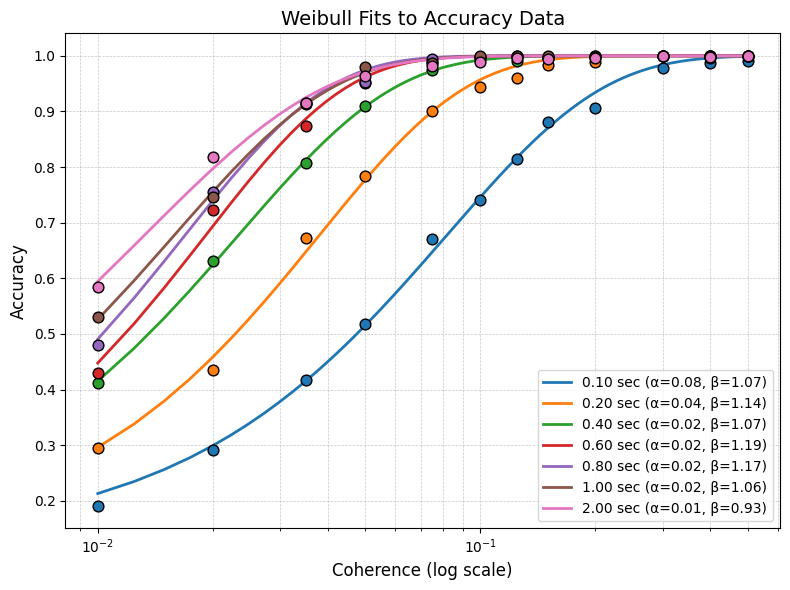

In [137]:
resolution = (128, 128)
samples_per_epoch = 512

# --- Define your parameter grid as a dictionary ---
param_grid = {
    'coherence': [0.01, 0.02, 0.035, 0.05, 0.075, 0.1, 0.125, 0.15, 0.2, 0.3, 0.4, 0.5],
    'n_frames': [4, 8, 16, 24, 32, 40, 80],
    'max_speed': [1],
    'n_dots': [100],
}

weibull_accuracies = generate_accuracies(classifier, cfg, samples_per_epoch, resolution, param_grid)

# Use a professional color palette
color_map = plt.get_cmap("tab10")  # or try "Set2", "tab20", "Dark2", etc.

# Example Weibull function
def weibull_func(x, alpha, beta):
    return 1 - (7/8) * np.exp(-((x / alpha) ** beta))

# Given arrays
n_frames_list = param_grid["n_frames"]
coherences = param_grid["coherence"]

# 1 frame is 0.025 seconds

timestamps = np.array(param_grid["n_frames"]) * 0.025

fit_params = {}

plt.figure(figsize=(8, 6))
mpl.rcParams.update({'axes.prop_cycle': mpl.cycler(color=[color_map(i) for i in range(len(param_grid["n_frames"]))])})

for n_frames_idx, n_frames in enumerate(n_frames_list):
    accuracies = weibull_accuracies[:, n_frames_idx, 0, 0]
    # Fit Weibull curve
    try:
        popt, _ = curve_fit(weibull_func, coherences, accuracies, p0=[0.2, 2.0], bounds=(0, np.inf))
        alpha, beta = popt
    except RuntimeError:
        alpha, beta = np.nan, np.nan
    
    fit_params[n_frames_idx] = (alpha, beta)

    # Plot fitted curve
    x_fit = np.linspace(min(coherences), max(coherences), 200)
    y_fit = weibull_func(x_fit, alpha, beta)

    # Assign color from the palette
    color = color_map(n_frames_idx % color_map.N)

    # Plot fitted curve first (line)
    line, = plt.plot(x_fit, y_fit, "-", label=f"{timestamps[n_frames_idx]:.2f} sec (α={alpha:.2f}, β={beta:.2f})", color=color, linewidth=2)

    # Use the same color for the scatter points, with a professional marker
    plt.scatter(coherences, accuracies, color=color, marker="o", edgecolor="k", s=60, zorder=3)

plt.xscale("log")
plt.xlabel("Coherence (log scale)", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.legend(frameon=True, fontsize=10, loc="best")
plt.title("Weibull Fits to Accuracy Data", fontsize=14)
plt.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.show()

# OOD Inputs

## Low Coherence

In [ ]:
resolution = (128, 128)
samples_per_epoch = 512

# --- Define your parameter grid as a dictionary ---
param_grid = {
    'coherence': np.logspace(np.log10(0.005), np.log10(0.25), 20).tolist(),
    'n_frames': [40],
    'max_speed': [1],
    'n_dots': [100],
    'num_bars': [0],
    'bar_width': [0],
    'dot_shape': ['point'],
    'dot_radius': [3],
    'jitter_speed': [0.0],
    'evidence_pulses': [None],
}

all_accuracies = generate_accuracies(classifier, cfg, samples_per_epoch, resolution, param_grid)
all_cnn_accuracies = generate_accuracies(cnn_classifier, cnn_cfg, samples_per_epoch, resolution, param_grid)

  0%|          | 0/20 [00:00<?, ?it/s]

100%|██████████| 20/20 [02:05<00:00,  6.28s/it]


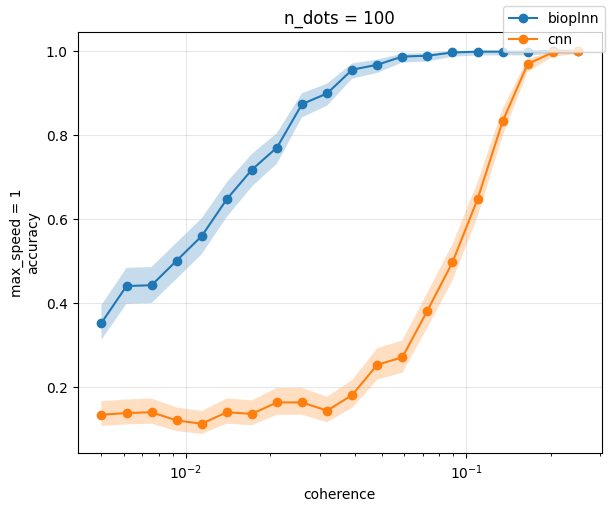

In [ ]:
def wilson_ci(p, n, z=1.96):psychophysics_accuraciesweibullWeibullwefdffdfdfdfdwee
    """
    p: array of accuracies in [0,1]
    n: number of Bernoulli trials
    Returns: lo, hi arrays
    """
    p = np.asarray(p)
    denom = 1 + z**2 / n
    center = (p + z**2 / (2*n)) / denom
    half = z * np.sqrt((p*(1-p) + z**2/(4*n)) / n) / denom
    return center - half, center + half

n_frames_idx = -1
num_trials = samples_per_epoch

coh = np.asarray(param_grid["coherence"])
max_speeds = param_grid["max_speed"]
n_dots_list = param_grid["n_dots"]

fig, axes = plt.subplots(
    len(max_speeds),
    len(n_dots_list),
    figsize=(6 * len(n_dots_list), 5 * len(max_speeds)),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

axes = np.atleast_2d(axes)

for i_speed, speed in enumerate(max_speeds):
    for j_dots, nd in enumerate(n_dots_list):
        ax = axes[i_speed, j_dots]

        bio = all_accuracies[:, n_frames_idx, i_speed, j_dots].squeeze()
        cnn = all_cnn_accuracies[:, n_frames_idx, i_speed, j_dots].squeeze()

        bio_lo, bio_hi = wilson_ci(bio, num_trials)
        cnn_lo, cnn_hi = wilson_ci(cnn, num_trials)

        ax.plot(coh, bio, label="bioplnn", marker="o")
        ax.plot(coh, cnn, label="cnn", marker="o")
        ax.fill_between(coh, bio_lo, bio_hi, alpha=0.25)
        ax.fill_between(coh, cnn_lo, cnn_hi, alpha=0.25)

        if i_speed == 0:
            ax.set_title(f"n_dots = {nd}")
        if j_dots == 0:
            ax.set_ylabel(f"max_speed = {speed}\naccuracy")

        ax.grid(True, alpha=0.3)

for ax in axes[-1]:
    ax.set_xlabel("coherence")

for ax in axes.flat:
    ax.set_xscale("log")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")

plt.show()

## Irregular Shapes, Movements, and Occlusion

In [134]:
resolution = (128, 128)
samples_per_epoch = 512

# --- Define your parameter grid as a dictionary ---
param_grid = {
    'coherence': [0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5],
    'n_frames': [40],
    'max_speed': [1],
    'n_dots': [100],
    'num_bars': [4, 8, 12],
    'bar_width': [4, 8],
    'dot_shape': ['point'],
    'dot_radius': [3],
    'jitter_speed': [0.0],
    'evidence_pulses': [None],
}

all_accuracies = generate_accuracies(classifier, cfg, samples_per_epoch, resolution, param_grid)
all_cnn_accuracies = generate_accuracies(cnn_classifier, cnn_cfg, samples_per_epoch, resolution, param_grid)

100%|██████████| 42/42 [05:11<00:00,  7.42s/it]


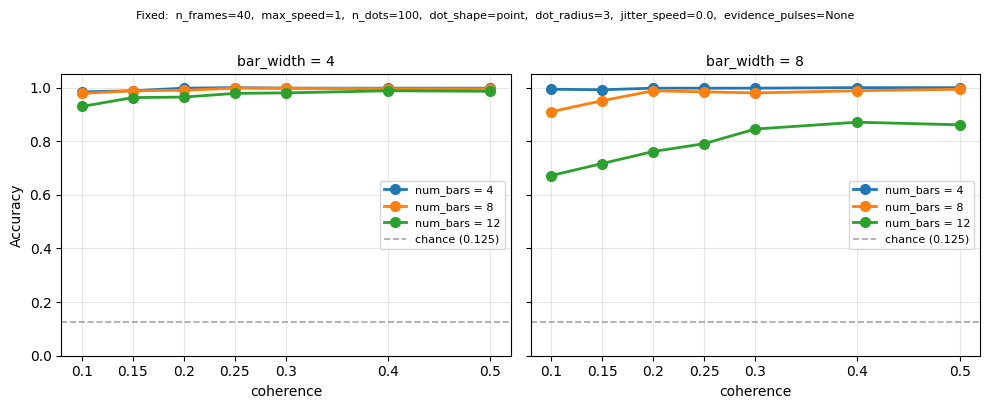

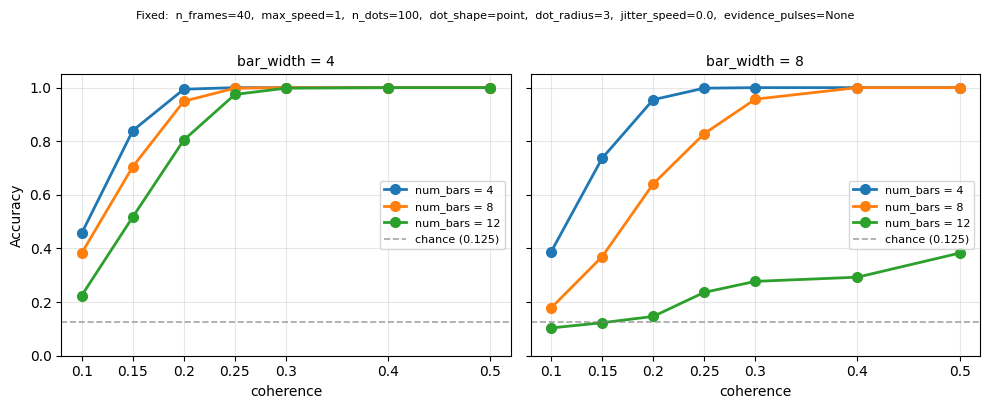

In [135]:
n_classes = cfg["model_config"].get("num_classes", 8)
plot_accuracies(all_accuracies, param_grid, chance_level=1/n_classes)
plot_accuracies(all_cnn_accuracies, param_grid, chance_level=1/n_classes)

# Evidence Pulse Timing

Sweep a brief evidence pulse across the sequence and measure how pulse timing affects the model's final decision. Two pulse types are tested at each start frame:

- **Positive** `(direction=+1)`: coherence is temporarily doubled — extra signal
- **Negative** `(direction=-1)`: the coherent direction is reversed — misleading signal

The two-panel figure shows raw accuracy and the accuracy delta relative to a no-pulse baseline. Horizontal error bars span the full pulse window `[start_t, start_t + duration]`.


In [99]:
n_frames      = 40
pulse_duration = 5
pulse_starts   = list(range(0, n_frames, pulse_duration))

# Build the evidence_pulses sweep:
#   index 0          → no pulse (baseline)
#   indices 1..N     → positive pulse starting at each frame in pulse_starts
#   indices N+1..2N  → negative pulse starting at each frame in pulse_starts
pulse_options = (
    [None]
    + [[(t, pulse_duration, +1)] for t in pulse_starts]
    + [[(t, pulse_duration, -1)] for t in pulse_starts]
)

param_grid_pulse = {
    'coherence':       [0.05],
    'n_frames':        [n_frames],
    'max_speed':       [1],
    'n_dots':          [100],
    'num_bars':        [0],
    'bar_width':       [0],
    'dot_shape':       ['point'],
    'dot_radius':      [1],
    'jitter_speed':    [0.0],
    'evidence_pulses': pulse_options,
}

accs_pulse = generate_accuracies(classifier, cfg, 512, resolution, param_grid_pulse)

  0%|          | 0/17 [00:00<?, ?it/s]

100%|██████████| 17/17 [02:07<00:00,  7.51s/it]


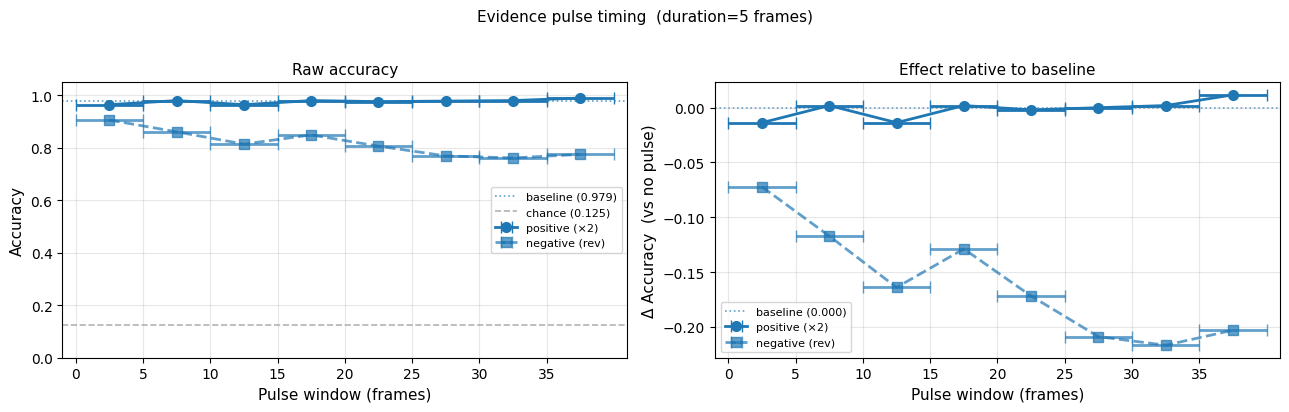

In [101]:
def plot_pulse_timing(accs, param_grid, pulse_starts, pulse_duration,
                      chance_level=None, title=None):
    """
    Two-panel figure: raw accuracy (left) and delta vs. baseline (right).

    Expects param_grid['evidence_pulses'] to be structured as:
        [None, pos_pulse_t0, ..., neg_pulse_t0, ...]
    where None = no-pulse baseline, direction +1 = positive, direction -1 = negative.

    Any other parameters with multiple values in param_grid become separate
    colored curves. Within each color, solid circles = positive pulse,
    dashed squares = negative pulse, dotted line = baseline.
    """
    param_names      = list(param_grid.keys())
    param_value_lists = [param_grid[k] for k in param_names]
    ev_list          = param_grid['evidence_pulses']
    pulse_dim        = param_names.index('evidence_pulses')
    n_frames         = param_grid['n_frames'][0]

    # Other dimensions that have more than one value (e.g. coherence)
    other_varying = [
        (name, vals, dim)
        for dim, (name, vals) in enumerate(zip(param_names, param_value_lists))
        if name != 'evidence_pulses' and len(vals) > 1
    ]
    other_names = [n for n, v, d in other_varying]
    other_vals  = [v for n, v, d in other_varying]
    other_dims  = [d for n, v, d in other_varying]
    combos = list(itertools.product(*other_vals)) if other_varying else [()]

    def extract_pulse_slice(combo):
        """Return 1-D array of length len(ev_list) for this combo of other params."""
        idx = [0] * accs.ndim
        for (name, vals, dim), val in zip(other_varying, combo):
            idx[dim] = vals.index(val)
        idx[pulse_dim] = slice(None)
        return accs[tuple(idx)]   # shape (len(ev_list),)

    def parse_slice(arr1d):
        baseline, pos, neg = None, {}, {}
        for i, ep in enumerate(ev_list):
            a = float(arr1d[i])
            if ep is None:
                baseline = a
            else:
                start_t, _, direction = ep[0]
                (pos if direction > 0 else neg)[start_t] = a
        return baseline, pos, neg

    centers = [t + pulse_duration / 2 for t in pulse_starts]
    xerr    = pulse_duration / 2
    colors  = plt.rcParams['axes.prop_cycle'].by_key()['color']

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    for ci, combo in enumerate(combos):
        color     = colors[ci % len(colors)]
        arr       = extract_pulse_slice(combo)
        base, pos_accs, neg_accs = parse_slice(arr)

        combo_label = ", ".join(f"{n}={v}" for n, v in zip(other_names, combo))
        suffix      = f"  [{combo_label}]" if combo_label else ""

        pos_raw   = [pos_accs.get(t, np.nan) for t in pulse_starts]
        neg_raw   = [neg_accs.get(t, np.nan) for t in pulse_starts]
        pos_delta = [v - base for v in pos_raw]
        neg_delta = [v - base for v in neg_raw]

        for ax, ypos, yneg, ybase in [
            (axes[0], pos_raw,   neg_raw,   base),
            (axes[1], pos_delta, neg_delta, 0.0),
        ]:
            ax.axhline(ybase, color=color, linestyle=':', linewidth=1.2,
                       label=f'baseline ({ybase:.3f}){suffix}', zorder=1, alpha=0.7)
            ax.errorbar(centers, ypos, xerr=xerr, color=color,
                        fmt='o-', capsize=4, linewidth=2, markersize=7, zorder=3,
                        label=f'positive (×2){suffix}')
            ax.errorbar(centers, yneg, xerr=xerr, color=color,
                        fmt='s--', capsize=4, linewidth=2, markersize=7, zorder=3,
                        label=f'negative (rev){suffix}', alpha=0.7)

    # Shared decoration
    for ax in axes:
        ax.set_xlabel('Pulse window (frames)', fontsize=11)
        ax.set_xlim(-1, n_frames + 1)
        ax.set_xticks(pulse_starts)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)

    if chance_level is not None:
        axes[0].axhline(chance_level, color='gray', linestyle='--', linewidth=1.2,
                        alpha=0.6, label=f'chance ({chance_level:.3g})', zorder=0)
        axes[0].legend(fontsize=8)

    axes[0].set_ylabel('Accuracy', fontsize=11)
    axes[0].set_ylim(0, 1.05)
    axes[0].set_title('Raw accuracy', fontsize=11)

    axes[1].set_ylabel('Δ Accuracy  (vs no pulse)', fontsize=11)
    axes[1].set_title('Effect relative to baseline', fontsize=11)

    if title:
        fig.suptitle(title, fontsize=11, y=1.02)
    plt.tight_layout()
    plt.show()


n_classes = cfg["model_config"].get("num_classes", 8)
plot_pulse_timing(
    accs_pulse, param_grid_pulse, pulse_starts, pulse_duration,
    chance_level=1 / n_classes,
    title=f"Evidence pulse timing  (duration={pulse_duration} frames)",
)


# Dynamical Analysis Code

In [ ]:
def keep_only_label_from_loader(loader, target_labels, batch_size=None, shuffle=False):
    xs, ys = [], []
    for x, y in loader:
        # make labels 1-D over batch
        if y.ndim > 1:
            # if one-hot/probabilities, reduce to class id
            if y.size(-1) > 1:
                y_flat = y.argmax(dim=-1)
            else:
                y_flat = y.squeeze(-1)
        else:
            y_flat = y

        mask = False
        for label in target_labels:
            mask = mask | (y_flat == label)
        if mask.any():
            xs.append(x[mask, ...])                # index batch dim only
            ys.append(y_flat[mask])

    X = torch.cat(xs, dim=0)
    Y = torch.cat(ys, dim=0)
    ds = TensorDataset(X, Y)
    return DataLoader(
        ds,
        batch_size or loader.batch_size,
        shuffle=shuffle,
        num_workers=loader.num_workers,
        pin_memory=loader.pin_memory,
        drop_last=loader.drop_last,
    )

# ----- MEM UTILS -----
def _bytes(n):
    for unit in ["B","KB","MB","GB","TB"]:
        if n < 1024: return f"{n:.2f} {unit}"
        n /= 1024
    return f"{n:.2f} PB"

def _cpu_rss_bytes():
    try:
        import psutil
        return psutil.Process(os.getpid()).memory_info().rss
    except Exception:
        # Fallback: resource gets maxrss; not perfect, but better than nothing
        try:
            import resource
            r = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
            # macOS reports bytes, Linux reports KB
            return r if r > 10**9 else r * 1024
        except Exception:
            return 0

def _cuda_bytes():
    if torch.cuda.is_available():
        dev = torch.cuda.current_device()
        alloc = torch.cuda.memory_allocated(dev)
        reserv = torch.cuda.memory_reserved(dev)
        max_alloc = torch.cuda.max_memory_allocated(dev)
        return alloc, reserv, max_alloc
    return 0, 0, 0

def log_mem(tag):
    rss = _cpu_rss_bytes()
    alloc, reserv, max_alloc = _cuda_bytes()
    msg = (
        f"[{time.strftime('%H:%M:%S')}] {tag} | "
        f"CPU RSS: {_bytes(rss)} "
        f"| CUDA alloc: {_bytes(alloc)} "
        f"reserved: {_bytes(reserv)} "
        f"peak: {_bytes(max_alloc)}"
    )
    print(msg, flush=True)

def estimate_host_bytes(num_samples, num_steps, dim, store_inputs=True, dtype_bytes=4):
    """
    Rough lower bound of arrays you preallocate (not counting transient copies).
    e_a: (N, T, 8, dim, dim) float32
    final_inputs: (N, T, 1, 128, 128) float32 if store_inputs
    """
    e_bytes = num_samples * num_steps * 8 * dim * dim * dtype_bytes
    fi_bytes = num_samples * num_steps * 1 * 128 * 128 * dtype_bytes if store_inputs else 0
    return e_bytes + fi_bytes

def get_activations(model, classifier, num_samples, loader, decision_step, num_steps=20, dim=48, device=None, memory_monitor=False, precision="float32"):
    if device is None:
        device = next(model.parameters()).device

    # quick estimate up-front
    approx = estimate_host_bytes(num_samples, num_steps, dim, store_inputs=True, dtype_bytes=4)
    print(f"[estimate] Lower-bound host memory footprint (preallocs only): {_bytes(approx)}", flush=True)

    if memory_monitor:
        log_mem("start")

    # choose a sorted subset of indices
    all_indices = np.arange(len(loader.dataset))
    subset_indices = np.random.choice(all_indices, size=num_samples, replace=False)
    subset_indices = np.sort(subset_indices)

    # wrap dataset
    subset_dataset = Subset(loader.dataset, subset_indices)

    # mirror original loader settings where possible
    dataloader = DataLoader(
        subset_dataset,
        batch_size=loader.batch_size,
        shuffle=False,  # keep consistent ordering for preallocation fill
        num_workers=getattr(loader, "num_workers", 0),
        pin_memory=getattr(loader, "pin_memory", False),
        drop_last=False
    )

    # preallocate
    if precision == "float16":
        dtype = np.float16
    elif precision == "float32":    
        dtype = np.float32
    else:
        raise ValueError(f"Unknown precision: {precision}")
        
    e_a = np.zeros((num_samples, num_steps, 8, dim, dim), dtype=dtype)
    i_a = None  # np.zeros((num_samples, num_steps, 4, dim, dim), dtype=np.float32)
    o_a = None  # np.zeros((num_samples, num_steps, 8, dim, dim), dtype=np.float32)
    decisions = np.zeros((num_samples,), dtype=np.int64)

    if memory_monitor:
        log_mem("after preallocs")

    model.eval()
    classifier.eval()
    classifier.to(device)

    final_labels = []

    # CUDA peak stats baseline
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()

    sample_idx = 0
    with torch.no_grad():
        for batch_idx, (batch_inputs, labels) in enumerate(tqdm(dataloader)):
            if memory_monitor:
                log_mem(f"batch {batch_idx} - fetched from loader")

            bsz = batch_inputs.shape[0]

            # move to device
            batch_inputs = batch_inputs.to(device, non_blocking=True)
            if memory_monitor:
                log_mem(f"batch {batch_idx} - after to(device)")

            # forward core model
            batch_output_states, batch_neuron_states, batch_feedback_states = model(
                batch_inputs, num_steps=num_steps
            )
            if memory_monitor:
                log_mem(f"batch {batch_idx} - after model()")

            # collect outputs on CPU
            # NOTE: .cpu().numpy() creates a *new* CPU array (extra RAM). Track this explicitly.
            o = batch_output_states[0].detach().cpu()  # (B, T, 8, dim, dim)
            if memory_monitor:
                log_mem(f"batch {batch_idx} - after o.cpu() (before numpy)")

            # if you don't need numpy immediately, stay in torch and convert when writing:
            o_np = o.numpy()  # temp CPU copy
            if memory_monitor:
                log_mem(f"batch {batch_idx} - after o.numpy()")

            e_t = model.query_neuron_states(batch_neuron_states, 0, 0).detach().cpu()
            if memory_monitor:
                log_mem(f"batch {batch_idx} - after e.cpu() (before numpy)")
            e = e_t.numpy()
            if memory_monitor:
                log_mem(f"batch {batch_idx} - after e.numpy()")

            i_t = model.query_neuron_states(batch_neuron_states, 0, 1).detach().cpu()
            if memory_monitor:
                log_mem(f"batch {batch_idx} - after i.cpu() (before numpy)")
            i = i_t.numpy()
            if memory_monitor:
                log_mem(f"batch {batch_idx} - after i.numpy()")

            # decisions (GPU -> small CPU copy)
            pred = classifier(batch_inputs, num_steps=decision_step)
            dec = torch.argmax(pred, dim=-1).detach().cpu().numpy()
            if memory_monitor:
                log_mem(f"batch {batch_idx} - after classifier + argmax")

            # write into preallocated buffers
            sl = slice(sample_idx, sample_idx + bsz)
            e_a[sl, :, :, :, :] = e
            # if i_a is enabled, uncomment this line:
            # i_a[sl, :, :, :, :] = i
            # if o_a is enabled, uncomment this line:
            # o_a[sl, :, :, :, :] = o_np
            decisions[sl] = dec
            final_labels.extend(labels.flatten().tolist())
            if memory_monitor:
                log_mem(f"batch {batch_idx} - after writes to preallocs")

            # ---- CLEAN UP TRANSIENTS to release host RAM ----
            del o, o_np, e_t, e, i_t, i, pred, dec
            del batch_output_states, batch_neuron_states, batch_feedback_states
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            gc.collect()
            if memory_monitor:
                log_mem(f"batch {batch_idx} - after gc/empty_cache")

            sample_idx += bsz

    if memory_monitor:
        log_mem("end")
    return {
        "e_a": e_a,
        "i_a": i_a,
        "o_a": o_a,
        "decisions": decisions,
        "labels": np.array(final_labels, dtype=np.int64),
    }

def get_decisions(classifier, dataloader, decision_step, device=None):
    if device is None:
        device = next(classifier.parameters()).device

    num_samples = len(dataloader.dataset)
    decisions = np.zeros((num_samples,), dtype=np.int64)

    classifier.eval()
    classifier.to(device)

    sample_idx = 0
    with torch.no_grad():
        for batch_inputs, _labels in tqdm(dataloader):
            bsz = batch_inputs.shape[0]
            batch_inputs = batch_inputs.to(device, non_blocking=True)
            # --- decisions in the same pass ---
            # your original code called classifier(batch_inputs, num_steps=decision_step) and argmax over last dim
            pred = classifier(batch_inputs, num_steps=decision_step)            # (B, num_classes) or similar
            dec = torch.argmax(pred, dim=-1).detach().cpu().numpy()            # (B,)

            # write into preallocated buffers
            sl = slice(sample_idx, sample_idx + bsz)
            decisions[sl] = dec
            sample_idx += bsz

    return decisions

class PCTrajectoryPlotter:
    """
    Fit PCA on (N, T, D) activations and plot trajectories using the fitted PCA.

    Usage:
        p = PCTrajectoryPlotter(max_components=10, random_state=0)
        p.fit(activations_train, decisions_train, balance_for_fit=False)
        p.plot(activations_val, decisions_val, n_components=2, ...)
        p.plot(activations_val, decisions_val, n_components=3, ...)
        p.plot(activations_val, decisions_val, n_components=5, ...)
    Key behaviors:
      - PCA is fit ONCE via `.fit(...)` with max_components. Later `.plot(...)` calls reuse it and can select n_components <= max_components.
      - You can pass different activations/decisions to `.plot(...)`.
      - Class color mapping is fixed based on classes seen at fit-time.
      - Overlay exemplars can be restricted to a subset of classes via `overlay_classes`.
      - plot_all_endpoints scatters the ENDPOINT of *all* trials, regardless of other settings.
    """

    def __init__(self, max_components=None, n_components=None, random_state=0):
        # Backward compatibility: n_components is an alias for max_components if max_components is not given
        if max_components is None and n_components is not None:
            max_components = n_components
        self.max_components = max_components
        self.random_state = random_state

        # For backward compatibility, keep n_components as a property
        self.n_components = max_components

        # PCA will be fit with max_components (or all if None)
        self.pca = None
        self.fitted_ = False

        # Fitted metadata
        self.classes_ = None            # sorted unique class values (as seen in decisions at fit time)
        self.class_to_index_ = None     # mapping from class value -> integer index
        self.color_map_ = None          # mapping from class index -> rgba
        self.cmap_name = 'viridis'
        self.fit_collapsed_ = False
        self._fit_D = None              # Number of features at fit time

    # ----------------------- Core utilities -----------------------

    @staticmethod
    def _check_inputs(A, y):
        A = np.asarray(A)
        y = np.asarray(y)
        assert A.ndim == 3, f"activations must be (N,T,D); got {A.shape}"
        N, T, D = A.shape
        assert y.shape[0] == N, f"decisions length {y.shape[0]} must match N {N}"
        return A, y, N, T, D

    @staticmethod
    def _balance_indices(y_num, rng):
        counts = np.bincount(y_num)
        k_bal = counts[counts > 0].min()
        uniq = np.unique(y_num)
        keep = np.concatenate([
            rng.choice(np.where(y_num == c)[0], k_bal, replace=False) for c in uniq
        ])
        keep.sort()
        return keep

    def _build_color_map(self, uniq_indices):
        cmap = plt.get_cmap(self.cmap_name)
        if len(uniq_indices) <= 1:
            return {uniq_indices[0]: cmap(0.5)}
        return {c: cmap(i / max(1, len(uniq_indices) - 1)) for i, c in enumerate(uniq_indices)}

    def _resolve_overlay_class_indices(self, overlay_classes):
        """Convert overlay_classes (values) to internal indices used at *plot time*.
           Any classes not seen at fit time are ignored silently."""
        if overlay_classes is None:
            # All fit-time classes
            return set(range(len(self.classes_)))
        out = set()
        for c in overlay_classes:
            if c in self.class_to_index_:
                out.add(self.class_to_index_[c])
        return out

    # ----------------------- Fit / Transform -----------------------

    def fit(self, activations, decisions, *, balance_for_fit=False, collapse_to_class_means=False):
        """
        Fit PCA on (N,T,D) activations.
          - balance_for_fit=True balances class counts before PCA.
          - collapse_to_class_means=True fits PCA on per-class mean trajectories only.
        """
        from sklearn.decomposition import PCA

        rng = np.random.default_rng(self.random_state)
        A, y, N, T, D = self._check_inputs(activations, decisions)
        self._fit_D = D

        # establish classes at fit time
        classes, y_num = np.unique(y, return_inverse=True)
        self.classes_ = classes
        self.class_to_index_ = {c: i for i, c in enumerate(classes)}

        if collapse_to_class_means:
            # one mean trajectory per class
            A_means = []
            for c in np.unique(y_num):
                idx = np.where(y_num == c)[0]
                A_means.append(A[idx].mean(axis=0))  # (T,D)
            A_fit = np.stack(A_means, axis=0)  # (C,T,D)
            X_fit = A_fit.reshape(-1, D)
            self.fit_collapsed_ = True
        else:
            if balance_for_fit:
                counts = np.bincount(y_num)
                k_bal = counts[counts > 0].min()
                keep = np.concatenate([
                    rng.choice(np.where(y_num == c)[0], k_bal, replace=False) for c in np.unique(y_num)
                ])
                keep.sort()
                A = A[keep]
            X_fit = A.reshape(-1, D)
            self.fit_collapsed_ = False

        # If max_components is None, use all possible components (D)
        n_components = self.max_components if self.max_components is not None else min(X_fit.shape[0], D)
        self.pca = PCA(n_components=n_components, random_state=self.random_state)
        self.pca.fit(X_fit)
        uniq_indices = np.arange(len(classes))
        self.color_map_ = self._build_color_map(uniq_indices)
        self.fitted_ = True
        return self

    def transform(self, activations, n_components=None):
        """
        Project (N,T,D) activations into PC space using fitted PCA.
        n_components: number of PCs to return (<= max_components fit at .fit time).
        """
        assert self.fitted_, "Call .fit(...) first."
        A = np.asarray(activations)
        assert A.ndim == 3
        N, T, D = A.shape
        if D != self._fit_D:
            raise ValueError(f"Input feature dimension {D} does not match fit-time dimension {self._fit_D}")
        pcs_all = self.pca.transform(A.reshape(-1, D)).reshape(N, T, -1)
        # Determine how many components to return
        if n_components is None:
            n_components = self.max_components if self.max_components is not None else pcs_all.shape[-1]
        if n_components > pcs_all.shape[-1]:
            raise ValueError(f"Requested n_components={n_components} > max_components fit ({pcs_all.shape[-1]})")
        return pcs_all[..., :n_components]

    # ----------------------- Plot helpers -----------------------

    def _pick_indices_per_class(self, y_num, pcs_trials, k, mode, overlay_class_indices, rng):
        """Pick exemplar indices per class using ENDPOINT distance (closest/farthest/random)."""
        uniq = np.unique(y_num)
        chosen = []
        for c in uniq:
            if c not in overlay_class_indices:
                continue
            idx = np.where(y_num == c)[0]
            if k <= 0 or k >= len(idx):
                chosen.extend(idx); continue
            pcs_c = pcs_trials[idx]  # [Nc, T, C]
            mean_end = pcs_c[:, -1, :].mean(axis=0)
            d_end = ((pcs_c[:, -1, :] - mean_end) ** 2).sum(axis=1)
            if mode == "closest":
                sel_local = np.argsort(d_end)[:k]
            elif mode == "farthest":
                sel_local = np.argsort(d_end)[-k:]
            elif mode == "random":
                sel_local = rng.choice(len(idx), size=k, replace=False)
            else:
                raise ValueError("overlay_mode must be 'closest', 'farthest', or 'random'")
            chosen.extend(np.array(idx)[sel_local])
        return sorted(chosen)

    def _scatter_all_endpoints(self, ax, pcs_trials, y_num, s=16, a=0.35, n_components=None, name_by_label=None):
        """Scatter ENDPOINT (t=T-1) for all trials (2D or 3D)."""
        uniq = np.unique(y_num)
        for c in uniq:
            ends = pcs_trials[y_num == c, -1, :]  # [Nc, C]
            col = self.color_map_.get(c, (0.5, 0.5, 0.5, 0.6))  # neutral if unseen at fit
            if n_components == 2:
                ax.scatter(ends[:, 0], ends[:, 1], s=s, marker='o', alpha=a, color=col) #, label=f"class {name_by_label[c]}")
            else:
                ax.scatter(ends[:, 0], ends[:, 1], ends[:, 2], s=s, marker='o', alpha=a, color=col) #, label=f"class {name_by_label[c]}")

    def _plot_exemplars(self, ax, pcs_trials, y_num, idxs, alpha=0.35, extra_point_timestep=None, n_components=None, name_by_label=None):
        """Plot exemplar trajectories for provided indices (2D or 3D)."""
        for i in idxs:
            c = y_num[i]
            col = self.color_map_.get(c, (0.5, 0.5, 0.5, 0.6))
            if n_components == 2:
                xy = pcs_trials[i, :, :2]
                ax.plot(xy[:, 0], xy[:, 1], '-', lw=1.0, alpha=alpha, color=col) #, label=f"class {name_by_label[c]}")
                ax.scatter(xy[0, 0], xy[0, 1], s=80, marker='*', color=col, alpha=alpha)
                ax.scatter(xy[-1, 0], xy[-1, 1], s=80, marker='o', color=col, alpha=alpha)
                if extra_point_timestep is not None:
                    ax.scatter(xy[extra_point_timestep, 0], xy[extra_point_timestep, 1], s=80, marker='o', color=col, alpha=alpha)
            else:
                xyz = pcs_trials[i, :, :3]
                ax.plot(xyz[:, 0], xyz[:, 1], xyz[:, 2], '-', lw=1.0, alpha=alpha, color=col) #, label=f"class {name_by_label[c]}")
                ax.scatter(xyz[0, 0], xyz[0, 1], xyz[0, 2], s=80, marker='*', color=col, alpha=alpha)
                ax.scatter(xyz[-1, 0], xyz[-1, 1], xyz[-1, 2], s=80, marker='o', color=col, alpha=alpha)
                if extra_point_timestep is not None:
                    ax.scatter(xyz[extra_point_timestep, 0], xyz[extra_point_timestep, 1], xyz[extra_point_timestep, 2], s=80, marker='o', color=col, alpha=alpha)

    # ----------------------- Plot -----------------------

    def plot_variance_explained(self, activations=None, decisions=None, show=True):
        """Plot the variance explained by each principal component."""
        if not self.fitted_:
            raise RuntimeError("Call .fit(...) before .plot_variance_explained(...)")
        pca = self.pca
        explained_variance = pca.explained_variance_ratio_
        plt.plot(explained_variance)
        plt.xlabel("Principal Component")
        plt.ylabel("Variance Explained")
        if show:
            plt.show()
        return explained_variance

    def plot(
        self,
        activations,
        decisions,
        *,
        n_components=None,
        title=None,
        balance=False,                # balance for the *plotting subset* (does not change PCA)
        per_class_mean=True,
        plot_trajectory=True,
        collapse_to_class_means=False,
        overlay_examples_k=0,
        overlay_mode="closest",       # 'closest'|'farthest'|'random'
        overlay_classes=None,         # list of class values from decisions; None => all fitted classes
        plot_all_endpoints=False,
        alpha=0.5,
        lw=1.5,
        random_state=None,            # optional override for picking exemplars
        show=True,                    # set False if you want to compose multiple plots
        return_data=False,            # return (pcs_used, pcs_means or None),
        extra_point_timestep=None,
        ax=None,                       # NEW: axes to plot into, if not None
        label_segments_with_timesteps=False,  # NEW: If True, label each segment with its timestep (start-end)
        selected_trials=None,
    ):
        """
        Plot trajectories for a (possibly different) dataset using the already-fitted PCA.
        n_components: number of PCs to use for plotting (2, 3, or more, up to max_components fit at .fit time).
        ax: matplotlib Axes (2D or 3D) to plot into. If None, a new figure/axes is created.
        label_segments_with_timesteps: If True, label each segment (between two points) with its timestep index.
        """
        assert self.fitted_, "Call .fit(...) before .plot(...)."

        # Default n_components: 2 if not specified
        if n_components is None:
            n_components = 2
        if n_components > self.pca.components_.shape[0]:
            raise ValueError(f"Requested n_components={n_components} > max_components fit ({self.pca.components_.shape[0]})")

        rng = np.random.default_rng(self.random_state if random_state is None else random_state)
        A, y, N, T, D = self._check_inputs(activations, decisions)

        # Map y (values) to fit-time class indices; unseen classes get index -1
        y_idx = np.array([self.class_to_index_.get(v, -1) for v in y], dtype=int)
        if np.any(y_idx < 0):
            # Warn once in a non-intrusive way (comment-friendly)
            # print("[PCTrajectoryPlotter] Warning: some classes were unseen at fit; using neutral color.")
            pass

        # Optional balancing for plotting set only
        if balance and not collapse_to_class_means:
            keep = self._balance_indices(np.clip(y_idx, 0, None), rng)  # clip to avoid negatives in bincount
            A = A[keep]
            y_idx = y_idx[keep]
            N = A.shape[0]

        # Transform with fitted PCA
        pcs_trials = self.transform(A, n_components=n_components)  # (N, T, n_components)

        # Legend labels based on fit-time classes only
        uniq_fit = np.arange(len(self.classes_))
        name_by_label = {i: str(self.classes_[i]) for i in uniq_fit}

        # Resolve overlay class set (in fit-time index space)
        overlay_class_indices = self._resolve_overlay_class_indices(overlay_classes)

        # -- Collapsed to class means --
        if collapse_to_class_means:
            # Build means over *current* data by fit-time class index
            uniq_current = np.unique(y_idx[y_idx >= 0])  # only known classes
            if len(uniq_current) == 0:
                raise ValueError("No samples with classes seen at fit-time; cannot compute class means.")
            T_ = pcs_trials.shape[1]
            pcs_means = np.zeros((len(uniq_fit), T_, n_components), dtype=pcs_trials.dtype)

            for c in uniq_fit:
                idx = np.where(y_idx == c)[0]
                if len(idx) > 0:
                    pcs_means[c] = pcs_trials[idx].mean(axis=0)
                else:
                    pcs_means[c] = np.nan  # no samples for this class in current data

            if n_components == 2:
                if ax is None:
                    fig, ax_ = plt.subplots(figsize=(6, 4))
                    ax = ax_
                # Exemplars first (subset of classes), if requested
                if overlay_examples_k > 0:
                    idxs = self._pick_indices_per_class(np.clip(y_idx, 0, None), pcs_trials,
                                                        overlay_examples_k, overlay_mode,
                                                        overlay_class_indices, rng)
                    self._plot_exemplars(ax, pcs_trials, np.clip(y_idx, 0, None), idxs, alpha=min(alpha, 0.75), extra_point_timestep=extra_point_timestep, n_components=n_components, name_by_label=name_by_label)
                if selected_trials is not None:
                    print(selected_trials)
                    self._plot_exemplars(ax, pcs_trials, np.clip(y_idx, 0, None), selected_trials, alpha=min(alpha, 0.75), extra_point_timestep=extra_point_timestep, n_components=n_components, name_by_label=name_by_label)
                # All endpoints cloud
                if plot_all_endpoints:
                    self._scatter_all_endpoints(ax, pcs_trials, np.clip(y_idx, 0, None), s=18, a=0.75, n_components=n_components)

                for c in uniq_fit:
                    col = self.color_map_.get(c, (0.6, 0.6, 0.6, 0.9))
                    m = pcs_means[c]
                    if np.isnan(m).any():
                        continue
                    ax.plot(m[:, 0], m[:, 1], '-', lw=3, color=col, label=f"class {name_by_label[c]} (mean)")
                    ax.scatter(m[0, 0], m[0, 1], s=80, marker='*', color=col)
                    ax.scatter(m[-1, 0], m[-1, 1], s=80, marker='o', color=col)
                    # Label segments with timesteps if requested
                    # if label_segments_with_timesteps:
                    #     for t in range(m.shape[0] - 1):
                    #         x0, y0 = m[t, 0], m[t, 1]
                    #         x1, y1 = m[t + 1, 0], m[t + 1, 1]
                    #         xm, ym = (x0 + x1) / 2, (y0 + y1) / 2
                    #         ax.text(xm, ym, f"{t}-{t+1}", fontsize=8, color=col, alpha=0.7, ha='center', va='center')
                ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2")
                ax.set_title(title or "Canonical class trajectories + exemplars")
                ax.legend(frameon=False)
                plt.tight_layout()
                if show and ax is not None and getattr(ax, 'figure', None) is not None:
                    plt.show()
            elif n_components == 3:
                from mpl_toolkits.mplot3d import Axes3D  # noqa
                if ax is None:
                    fig = plt.figure(figsize=(10, 8))
                    ax_ = fig.add_subplot(111, projection='3d')
                    ax = ax_
                if overlay_examples_k > 0:
                    idxs = self._pick_indices_per_class(np.clip(y_idx, 0, None), pcs_trials,
                                                        overlay_examples_k, overlay_mode,
                                                        overlay_class_indices, rng)
                    self._plot_exemplars(ax, pcs_trials, np.clip(y_idx, 0, None), idxs, alpha=min(alpha, 0.75), n_components=n_components, name_by_label=name_by_label)
                if plot_all_endpoints:
                    self._scatter_all_endpoints(ax, pcs_trials, np.clip(y_idx, 0, None), s=18, a=min(alpha, 0.75), n_components=n_components, name_by_label=name_by_label)

                for c in uniq_fit:
                    col = self.color_map_.get(c, (0.6, 0.6, 0.6, 0.9))
                    m = pcs_means[c]
                    if np.isnan(m).any():
                        continue
                    ax.plot(m[:, 0], m[:, 1], m[:, 2], '-', lw=3, color=col,
                            label=f"class {name_by_label[c]} (mean)")
                    ax.scatter(m[0, 0], m[0, 1], m[0, 2], s=80, marker='*', color=col)
                    ax.scatter(m[-1, 0], m[-1, 1], m[-1, 2], s=80, marker='o', color=col)
                    # Label segments with timesteps if requested
                    # if label_segments_with_timesteps:
                    #     for t in range(m.shape[0] - 1):
                    #         x0, y0, z0 = m[t, 0], m[t, 1], m[t, 2]
                    #         x1, y1, z1 = m[t + 1, 0], m[t + 1, 1], m[t + 1, 2]
                    #         xm, ym, zm = (x0 + x1) / 2, (y0 + y1) / 2, (z0 + z1) / 2
                    #         ax.text(xm, ym, zm, f"{t}-{t+1}", fontsize=8, color=col, alpha=0.7, ha='center', va='center')
                ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2"); ax.set_zlabel("PC 3")
                ax.set_title(title or "Canonical class trajectories + exemplars")
                plt.tight_layout()
                if show and ax is not None and getattr(ax, 'figure', None) is not None:
                    plt.show()
            else:
                raise ValueError("Only 2D or 3D plotting is supported for collapsed class means.")
            return (pcs_trials, pcs_means) if return_data else None

        # -- Non-collapsed trajectories --
        # Choose exemplar indices (subset of classes)
        idxs = []
        if overlay_examples_k > 0:
            idxs = self._pick_indices_per_class(np.clip(y_idx, 0, None), pcs_trials,
                                                overlay_examples_k, overlay_mode,
                                                overlay_class_indices, rng)

        if n_components == 2:
            if ax is None:
                fig, ax_ = plt.subplots(figsize=(8, 6))
                ax = ax_
            # Plot the exemplar trajectories
            if idxs:
                self._plot_exemplars(ax, pcs_trials, np.clip(y_idx, 0, None), idxs, alpha=min(alpha, 0.75), n_components=n_components, name_by_label=name_by_label)
            if selected_trials is not None:
                self._plot_exemplars(ax, pcs_trials, np.clip(y_idx, 0, None), selected_trials, alpha=min(alpha, 0.75), extra_point_timestep=extra_point_timestep, n_components=n_components, name_by_label=name_by_label)

            # Plot the selected (same exemplar set) or all? — follow original: draw only chosen exemplars
            # But add class means if requested (computed over all trials in current data)
            if per_class_mean:
                for c in np.unique(np.clip(y_idx, 0, None)):
                    if c < 0:  # skip unseen
                        continue
                    m = pcs_trials[y_idx == c].mean(axis=0)  # (T, C)
                    col = self.color_map_.get(c, (0.6, 0.6, 0.6, 0.9))
                    ax.plot(m[:, 0], m[:, 1], '-', lw=3, color=col, label=f"class {name_by_label[c]} (mean)")
                    # # Label segments with timesteps if requested
                    if label_segments_with_timesteps and not hasattr(ax, "_timesteps_labeled"):
                        print("labeling timesteps")
                        for t in range(0, m.shape[0] - 1, 2):
                            x0, y0 = m[t, 0], m[t, 1]
                            x1, y1 = m[t + 1, 0], m[t + 1, 1]
                            xm, ym = (x0 + x1) / 2, (y0 + y1) / 2
                            ax.text(xm, ym, f"{t}-{t+1}", fontsize=8, color=col, alpha=0.7, ha='center', va='center')
                        ax._timesteps_labeled = True

            # Optional: cloud of all endpoints
            if plot_all_endpoints:
                self._scatter_all_endpoints(ax, pcs_trials, np.clip(y_idx, 0, None), s=16, a=min(alpha, 0.75), n_components=n_components)

            ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2")
            
        elif n_components == 3:
            from mpl_toolkits.mplot3d import Axes3D  # noqa
            if ax is None:
                fig = plt.figure(figsize=(10, 8))
                ax_ = fig.add_subplot(111, projection='3d')
                ax = ax_
            if idxs:
                self._plot_exemplars(ax, pcs_trials, np.clip(y_idx, 0, None), idxs, alpha=min(alpha, 0.75), n_components=n_components, name_by_label=name_by_label)

            if per_class_mean:
                for c in np.unique(np.clip(y_idx, 0, None)):
                    if c < 0:  # skip unseen
                        continue
                    m = pcs_trials[y_idx == c].mean(axis=0)  # (T, C)
                    col = self.color_map_.get(c, (0.6, 0.6, 0.6, 0.9))
                    ax.plot(m[:, 0], m[:, 1], m[:, 2], '-', lw=3, color=col,
                            label=f"class {name_by_label[c]} (mean)")
                    # Label segments with timesteps if requested
                    # if label_segments_with_timesteps:
                    #     for t in range(m.shape[0] - 1):
                    #         x0, y0, z0 = m[t, 0], m[t, 1], m[t, 2]
                    #         x1, y1, z1 = m[t + 1, 0], m[t + 1, 1], m[t + 1, 2]
                    #         xm, ym, zm = (x0 + x1) / 2, (y0 + y1) / 2, (z0 + z1) / 2
                    #         ax.text(xm, ym, zm, f"{t}-{t+1}", fontsize=8, color=col, alpha=0.7, ha='center', va='center')
                
            if plot_all_endpoints:
                self._scatter_all_endpoints(ax, pcs_trials, np.clip(y_idx, 0, None), s=16, a=min(alpha, 0.75), n_components=n_components)
            
            ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2"); ax.set_zlabel("PC 3")
            
        # Only plot one legend entry per class, using name_by_label
        handles = []
        labels = []
        for c in np.unique(np.clip(y_idx, 0, None)):
            if c < 0:
                continue
            col = self.color_map_.get(c, (0.6, 0.6, 0.6, 0.9))
            # Create a proxy artist for the legend
            # For 2D and 3D, handle legend proxy accordingly
            if n_components == 2:
                h = ax.plot([], [], '-', lw=3, color=col)[0]
            elif n_components == 3:
                h = ax.plot([], [], [], '-', lw=3, color=col)[0]
            else:
                continue
            handles.append(h)
            labels.append(f"class {name_by_label[c]}")
        if handles:
            ax.legend(handles, labels, frameon=False)
        
        ax.set_title(title or "Trajectories in PC space")
        plt.tight_layout()
        if show and ax is not None and getattr(ax, 'figure', None) is not None:
            plt.show()
        elif not (n_components == 2 or n_components == 3):
            raise ValueError("Only 2D or 3D plotting is supported for non-collapsed trajectories.")

        return pcs_trials if return_data else None

## Decoder Functions

In [ ]:
class MLPDecoder(nn.Module):
    def __init__(self, D, hidden=128, out_dim=8, dropout=0.0):
        super().__init__()
        self.fc1 = nn.Linear(D, hidden)
        self.drop = nn.Dropout(dropout) if dropout > 0 else nn.Identity()
        self.fc2 = nn.Linear(hidden, out_dim)
    def forward(self, x):                # x: [N, D]
        h = F.relu(self.fc1(x))
        h = self.drop(h)
        return self.fc2(h)               # logits or scalar(s)
    def project_hidden(self, x):         # get hidden features [N, hidden]
        return F.relu(self.fc1(x))


def train_mlp_decoder(
    X, y, X_test, y_t_test, *, hidden=128, task="multiclass", out_dim=None,
    epochs=20, bs=128, lr=1e-3, weight_decay=0.0, device=None, dropout=0.0
):
    """
    Trains an MLP (input -> hidden -> output) and returns the model with the LOWEST val loss.
    X: float [N,D], y: [N]
    X_test, y_t_test: validation set
    """
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"
    N, D = X.shape
    if out_dim is None:
        if task == "multiclass":
            C_train = int(y.max().item()) + 1
            C_val   = int(y_t_test.max().item()) + 1
            out_dim = max(C_train, C_val)
        else:
            out_dim = 1

    model = MLPDecoder(D, hidden=hidden, out_dim=out_dim, dropout=dropout).to(device)

    # loss + label shaping
    def prep_y(lbl):
        if task == "multiclass":
            return lbl.long()
        elif task == "binary":
            return lbl.float().unsqueeze(1)
        elif task == "regression":
            return lbl.float().unsqueeze(1) if out_dim == 1 else lbl.float()
        else:
            raise ValueError("task must be 'multiclass'|'binary'|'regression'")

    y_tr  = prep_y(y)
    y_val = prep_y(y_t_test)

    if task == "multiclass":
        crit = nn.CrossEntropyLoss()
    elif task == "binary":
        crit = nn.BCEWithLogitsLoss()
    else:
        crit = nn.MSELoss()

    tr_dl = DataLoader(TensorDataset(X, y_tr), batch_size=bs, shuffle=True)
    va_dl = DataLoader(TensorDataset(X_test, y_val), batch_size=bs, shuffle=False)

    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_val = float("inf")
    best_state = None
    best_epoch = -1

    for ep in tqdm(range(1, epochs + 1)):
        # ---- train
        model.train()
        for xb, yb in tr_dl:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = crit(logits, yb)
            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()

        # ---- validate
        model.eval()
        val_sum, n_batches = 0.0, 0
        with torch.no_grad():
            for xb, yb in va_dl:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                val_sum += crit(logits, yb).item()
                n_batches += 1
        val_loss = val_sum / max(1, n_batches)

        # track best
        if val_loss < best_val - 1e-9:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            best_epoch = ep

        # optional: print progress
        # print(f"epoch {ep}: val_loss={val_loss:.4f} (best={best_val:.4f} @ {best_epoch})")

    # restore best weights
    if best_state is not None:
        model.load_state_dict(best_state)

    return model, {"best_val_loss": best_val, "best_epoch": best_epoch}
    
import torch, torch.nn as nn

@torch.no_grad()
def hidden_from_mlp(model, X, *, apply_relu=True, batch_size=0, device=None):
    """
    X: [N, D]  ->  returns H: [N, hidden]
    Looks for model.fc1 (nn.Linear); falls back to the first Linear found.
    """
    model.eval()
    if device is None:
        device = next(model.parameters()).device

    # pick the linear layer that defines the hidden space
    lin = getattr(model, "fc1", None)
    if not isinstance(lin, nn.Linear):
        lin = next(m for m in model.modules() if isinstance(m, nn.Linear))

    def run_chunk(xb):
        h = lin(xb.to(device))
        return (torch.relu(h) if apply_relu else h).cpu()

    if not batch_size:
        return run_chunk(X)

    outs = []
    for s in range(0, X.size(0), batch_size):
        outs.append(run_chunk(X[s:s+batch_size]))
    return torch.cat(outs, dim=0)

# USE MODEL's READOUT WEIGHTS TO ON ACTIVATIONS OVER AT ANY STEP

def batched_readout_from_extracted(
    x,                 # (N, T, 8, H, W)
    conv_w, conv_b,    # [8, 8, 5, 5], [8]
    lin_w, lin_b,      # [512, 8], [512]
    use_relu=True,
    pool="max",        # "max" or "avg"
    padding=None       # None -> same-ish (k//2)
):
    """
    Returns (N, T, 512) from extracted weights:
      x -> conv2d(8->8,k=5) -> ReLU? -> Adaptive{pool}(1,1) -> Flatten -> Linear(8->512)
    """
    assert x.ndim == 5 and x.shape[2] == conv_w.shape[1] == 8, "Expect x:(N,T,8,H,W)"
    N, T, C, H, W = x.shape
    dev, dt = conv_w.device, conv_w.dtype

    # Flatten batch+time, move/dtype-match to weights
    x2 = x.reshape(N*T, C, H, W).to(device=dev, dtype=dt)

    # default "same" padding for odd kernel
    if padding is None:
        kH, kW = conv_w.shape[-2:]
        padding = (kH // 2, kW // 2)

    y = F.conv2d(x2, conv_w, conv_b, stride=1, padding=padding)
    if use_relu:
        y = F.relu(y)

    if pool == "max":
        y = F.adaptive_max_pool2d(y, (1, 1))
    elif pool == "avg":
        y = F.adaptive_avg_pool2d(y, (1, 1))
    else:
        raise ValueError("pool must be 'max' or 'avg'")

    y = y.view(N*T, -1)                 # (N*T, 8)
    out = F.linear(y, lin_w, lin_b)     # (N*T, 512)
    return out.view(N, T, -1)           # (N, T, 512)

## Load Data

In [ ]:
batch_size = 128
num_train_samples = batch_size * 20
num_test_samples = batch_size * 1

# DOTS

n_frames = 40
resolution = (128, 128)
correlation = (0.25,0.75)
directions = [0,1]
max_speed = 1
n_dots = 100
correlation = 0.04

n_extra_frames = 20

train_loader, test_loader = initialize_dataloader(
        seed=12, dataset="correlated_dots",
        resolution=resolution, n_frames=n_frames, correlation=correlation, max_speed=max_speed, samples_per_epoch=num_train_samples,
        batch_size=batch_size, directions=directions, n_dots=n_dots)
decision_step = n_frames
num_steps = n_frames
dim = resolution[0]
precision = "float32"


# # ADD A WORKING MEMORY PERIOD
if n_extra_frames > 0:
    # Add a blank period to every sample in train_loader and test_loader
    def add_blank_to_loader(loader, n_extra_frames, dim):
        # This function returns a new loader with blank frames appended to each sample
        from torch.utils.data import DataLoader, TensorDataset

        all_inputs = []
        all_labels = []
        for batch in loader:
            # batch[0]: (batch_size, n_frames, dim, dim)
            # batch[1]: labels
            inputs, labels = batch
            # Add blank period to each sample in the batch
            # blank_period: (n_extra_frames, dim, dim)
            blank = torch.zeros((inputs.shape[0], n_extra_frames, inputs.shape[2], dim, dim), dtype=inputs.dtype, device=inputs.device)
            inputs_with_blank = torch.cat([inputs, blank], dim=1)
            all_inputs.append(inputs_with_blank)
            all_labels.append(labels)
        all_inputs = torch.cat(all_inputs, dim=0)
        all_labels = torch.cat(all_labels, dim=0)
        new_dataset = TensorDataset(all_inputs, all_labels)
        new_loader = DataLoader(new_dataset, batch_size=loader.batch_size, shuffle=False)
        return new_loader

    train_loader = add_blank_to_loader(train_loader, n_extra_frames, dim)
    test_loader = add_blank_to_loader(test_loader, n_extra_frames, dim)
    num_steps = n_frames + n_extra_frames
    decision_step = num_steps

## Load Activations

In [ ]:
# # Collect activations and relevant data for train and test sets
train_activations = get_activations(
    model, classifier,
    num_samples=num_train_samples,
    loader=train_loader,
    decision_step=decision_step,
    num_steps=num_steps,
    dim=dim,
    precision=precision
)
train_ea, train_ia, train_oa, train_decisions, train_labels = train_activations["e_a"], train_activations["i_a"], train_activations["o_a"], train_activations["decisions"], train_activations["labels"]

test_activations = get_activations(
    model, classifier,
    num_samples=200,
    loader=test_loader,
    decision_step=decision_step,
    num_steps=num_steps,
    dim=dim,
    precision=precision
)
test_ea, test_ia, test_oa, test_decisions, test_labels = test_activations["e_a"], test_activations["i_a"], test_activations["o_a"], test_activations["decisions"], test_activations["labels"]

print(len(train_ea))

# CHOOSE CORRECT EXAMPLES ONLY
only_correct = False
if only_correct:
    save_idx_train = np.flatnonzero(np.squeeze(train_decisions) == np.squeeze(train_labels))
    train_ea, train_decisions, train_labels = [np.asarray(a)[save_idx_train] for a in (train_ea, train_decisions, train_labels)]
    save_idx_test = np.flatnonzero(np.squeeze(test_decisions) == np.squeeze(test_labels))
    test_ea, test_decisions, test_labels = [np.asarray(a)[save_idx_test] for a in (test_ea, test_decisions, test_labels)]

print(len(train_ea))

# # CHOOSE ONLY EXAMPLES THAT ARE CLASSIFIED AS ONE OF THE LABELS IN directions
idx = np.flatnonzero(np.isin(train_decisions, directions))
train_ea, train_decisions, train_labels = [np.asarray(a)[idx] for a in (train_ea, train_decisions, train_labels)]
idx = np.flatnonzero(np.isin(test_decisions, directions))
test_ea, test_decisions, test_labels = [np.asarray(a)[idx] for a in (test_ea, test_decisions, test_labels)]

print(len(train_ea))

error_trials = np.where(train_decisions != train_labels)[0]

## Decoding into $S_1$ and $S_2$

In [ ]:
train_steps = np.arange(30, 40) #this is what I've been using for most of the experiments
# train_steps = np.array([39])

act = train_ea[:, train_steps]
act = act.reshape(*act.shape[:-3], -1)
act = act.reshape(-1, act.shape[-1])

test_act = test_ea[:, train_steps]
test_act = test_act.reshape(*test_act.shape[:-3], -1)
test_act = test_act.reshape(-1, test_act.shape[-1])

#labels - decisions

train_dec_repeated = torch.tensor(train_decisions).repeat_interleave(len(train_steps))
test_dec_repeated = torch.tensor(test_decisions).repeat_interleave(len(train_steps))
decoder_train_labels = train_dec_repeated
decoder_test_labels = test_dec_repeated

In [ ]:
decoder_args = {
    "hidden": 32,
    "task": "multiclass",
    "epochs": 25,
    "dropout": 0.2,
    "lr": 4e-5,
    "bs": 256
}

precision = "float32"

decoder_model, results = train_mlp_decoder(
    torch.tensor(act, dtype=torch.float32),
    decoder_train_labels,
    torch.tensor(test_act, dtype=torch.float32),
    decoder_test_labels,
    **decoder_args
)

print(results)

In [ ]:
# test multiclass or binary tasks
with torch.no_grad():
    logits = decoder_model(torch.tensor(act, dtype=torch.float32).to(device))      # [N, 8]
    pred = logits.argmax(1)
    
    wrong = 0
    for i in range(len(pred)):
        if pred[i] != decoder_train_labels[i]:
            wrong += 1
    print(f"Train acc: {1-(wrong/len(pred))}")
        
    logits = decoder_model(torch.tensor(test_act, dtype=torch.float32).to(device))      # [N, 8]
    pred = logits.argmax(1)
        
    wrong = 0
    for i in range(len(pred)):
        if pred[i] != decoder_test_labels[i]:
            wrong += 1
    print(f"Val acc: {1-(wrong/len(pred))}")

## Fit PCA

In [ ]:
# X: [N, D]
start_idx = 0
end_idx = 40

#TRAIN
pca_acts = train_ea[:, start_idx:end_idx]
decisions = train_decisions

#TEST
# pca_acts = test_ea[:, start_idx:end_idx]
# decisions = test_decisions

num_samples = len(pca_acts)

pca_acts = pca_acts.reshape(*pca_acts.shape[:-3], -1)

### Project into Decoding Space

In [ ]:
pca_acts = pca_acts.reshape(-1, pca_acts.shape[-1])

# Process in batches to avoid OOM
batch_size = 1024
hidden_list = []
with torch.no_grad():
    for i in range(0, pca_acts.shape[0], batch_size):
        batch = pca_acts[i:i+batch_size]
        batch_hidden = hidden_from_mlp(decoder_model, torch.tensor(batch, dtype=torch.float32).to(device), apply_relu=True)
        hidden_list.append(batch_hidden.cpu())
pca_acts_hidden = torch.cat(hidden_list, dim=0).numpy()
pca_acts = pca_acts_hidden.reshape(num_samples, end_idx-start_idx, decoder_args["hidden"])

In [ ]:
p = PCTrajectoryPlotter(max_components=3)

# Train set (what you used to pass to plot_PC_trajectories)
p.fit(pca_acts, decisions, balance_for_fit=False, collapse_to_class_means=False)

# Trajectory Plot

In [ ]:
Z = p.plot(
    pca_acts[:, 2:], decisions,
    overlay_examples_k=3,
    overlay_mode="closest",     # 'closest' | 'farthest' | 'random'
    overlay_classes=None,       # None => all classes
    plot_all_endpoints=False,    # scatter ENDPOINTS for all trials
    per_class_mean=True,
    plot_trajectory=False,
    title="Coherence = 0.25",
    alpha=0.75,
    collapse_to_class_means=False,
    extra_point_timestep=39,
    n_components=3,
    return_data=True
)

# Phase Plot + Stability Analysis

In [ ]:
def rotate_45(trajs, normalize_axes=False, eps=1e-12, clockwise=False):
    """
    Rotate (d,z) trajectories by ±45°.

    Conventions:
        - Input columns: [...,0]=d (x-axis), [...,1]=z (y-axis)
        - clockwise=False: +45° (counterclockwise) rotation
        - clockwise=True:  -45° (clockwise) rotation

    Args:
        trajs: (N, T, 2) array with columns [...,0]=d and [...,1]=z
        normalize_axes: if True, z-score d and z across all points before rotation
        clockwise: if True, rotate by -45° instead of +45°
    Returns:
        trajs_rot: (N, T, 2) rotated coordinates
    """
    X = np.asarray(trajs)
    assert X.ndim == 3 and X.shape[2] == 2, "trajs must be (N,T,2)"

    d = X[..., 0]
    z = X[..., 1]

    if normalize_axes:
        d = (d - d.mean()) / (d.std() + eps)
        z = (z - z.mean()) / (z.std() + eps)

    inv_sqrt2 = 1.0 / np.sqrt(2.0)
    c = inv_sqrt2
    s = inv_sqrt2

    # Rotation matrix R(theta) applied to [d, z]^T:
    # [x']   [ c  -s] [d]
    # [y'] = [ s   c] [z]
    #
    # For theta = -45° (clockwise), just flip the sign of s.
    if clockwise:
        s = -s

    S1 = c * d - s * z
    S2 = s * d + c * z

    return np.stack([S1, S2], axis=-1)


# --------------------------------------------------------
# 2) Linearize in (S1,S2) around the decision boundary
#     (where |S1 - S2| is small; i.e., near the separatrix)
# --------------------------------------------------------
def linearize_in_S_space(trajs_S, dt=1.0, diff_band=0.05,
                         slow_quantile=0.1, neighborhood_radius=0.1,
                         min_samples=200, difference_method="central_difference"):
    """
    Linearize 2D dynamics in (S1,S2) near the decision boundary S1≈S2.

    Args:
        trajs_S: (N, T, 2) with columns [...,0]=S1, [...,1]=S2
        dt: time step between frames
        diff_band: selects boundary points where |S1 - S2| <= diff_band
        slow_quantile: among boundary points, keep slowest q-fraction to estimate s*
        neighborhood_radius: radius around s* for local linear fit
        min_samples: minimum samples for the fit (relaxes neighborhood if needed)
    Returns:
        s_star: (2,) estimated boundary slow-point (proxy for saddle)
        A: (2,2) local Jacobian so that  dot{s} ≈ A (s - s_star)
        evals: (2,) eigenvalues of A  [expect one >0, one <0 near saddle]
        evecs: (2,2) eigenvectors (columns) of A
        idx_neigh: (M,) indices of midstep samples used in the fit (flattened)
    """
    S = np.asarray(trajs_S)
    assert S.ndim == 3 and S.shape[2] == 2, "trajs_S must be (N,T,2)"
    N, T, _ = S.shape

    # midstep states & velocities

    if difference_method == "central_difference":
        dS = (S[:, 2:, :] - S[:, :-2, :]) / dt      # (N, T-2, 2)
        Smid = 0.5 * (S[:, 1:-1, :] + S[:, 2:, :])     # (N, T-2, 2)
    else:
        dS = (S[:, 1:, :] - S[:, :-1, :]) / dt      # (N, T-1, 2)
        Smid = 0.5 * (S[:, 1:, :] + S[:, :-1, :])     # (N, T-1, 2)

    # flatten across trials/time
    Sm = Smid.reshape(-1, 2)                      # positions
    dSm = dS.reshape(-1, 2)                       # velocities

    # boundary selection: |S1 - S2| small
    diff = Sm[:, 0] - Sm[:, 1]
    band_mask = np.abs(diff) <= diff_band
    if not np.any(band_mask):
        raise ValueError("No samples found near boundary; increase diff_band.")

    # pick slow points in the band to locate s*
    speeds = np.linalg.norm(dSm[band_mask], axis=1)
    q = max(1, int(np.ceil(slow_quantile * speeds.size)))
    slow_idx_band = np.argsort(speeds)[:q]
    slow_points = Sm[band_mask][slow_idx_band]
    s_star = slow_points.mean(axis=0)             # proxy for saddle location

    # local neighborhood around s*
    deltas = Sm - s_star[None, :]
    radii = np.linalg.norm(deltas, axis=1)
    neigh_mask = radii <= neighborhood_radius
    if neigh_mask.sum() < min_samples:
        # relax: take closest points until min_samples (or 2% of data)
        order = np.argsort(radii)
        take = max(min_samples, int(0.02 * Sm.shape[0]))
        neigh_mask = np.zeros_like(radii, dtype=bool)
        neigh_mask[order[:take]] = True

    ΔS = deltas[neigh_mask]    # (M,2)
    dS_loc = dSm[neigh_mask]   # (M,2)
    if ΔS.shape[0] < 2:
        raise ValueError("Insufficient neighborhood samples to fit A.")

    # linear fit with zero bias at s*:  dS ≈ A (S - s*)
    A_T, *_ = np.linalg.lstsq(ΔS, dS_loc, rcond=None)
    A = A_T.T

    evals, evecs = np.linalg.eig(A)
    idx_neigh = np.where(neigh_mask)[0]
    return s_star, A, evals, evecs, idx_neigh


In [ ]:
def midpts_and_vel(trajs_S, dt=1.0, difference_method="central_difference"):
    if difference_method == "central_difference":
        Sm  = 0.5*(trajs_S[:,1:-1,:] + trajs_S[:,2:,:]).reshape(-1, 2)
        dSm = (trajs_S[:,2:,:] - trajs_S[:,:-2,:]).reshape(-1, 2) / (2.0*dt)
    else:
        Sm  = 0.5*(trajs_S[:,1:,:] + trajs_S[:,:-1,:]).reshape(-1, 2)
        dSm = (trajs_S[:,1:,:] - trajs_S[:,:-1,:]).reshape(-1, 2) / dt
    return Sm, dSm

def local_fixed_point(
    S_trajs,
    dt=1.0,
    diff_band=0.05,
    min_samples=200,
    difference_method="central_difference",
    init_mode="band",              # 'band' | 'global' | 'around'
    center=None,                   # (x,y) for 'around'
    radius=None,                   # defaults to diff_band
    nbhd_frac=0.02,
    damp=1e-6,
    lambda_center=0.0,             # >=0; adds prior to keep s* near center (only used if init_mode='around')
    around_dilate=1.0              # multiply radius for the *final* linearization neighborhood (>=1.0)
):
    """
    Returns: s_star, A, evals, evecs, take2_indices
    """
    S = np.asarray(S_trajs); assert S.ndim==3 and S.shape[2]==2
    Sm, dSm = midpts_and_vel(S, dt=dt, difference_method=difference_method)
    speeds_all = np.linalg.norm(dSm, axis=1)

    # ----- build pool of candidate points -----
    if init_mode == "band":
        band = np.abs(Sm[:,0] - Sm[:,1]) <= diff_band
        if not np.any(band):
            raise ValueError("No samples satisfy |S1-S2| <= diff_band.")
        pool_idx = np.where(band)[0]

    elif init_mode == "global":
        pool_idx = np.arange(Sm.shape[0])

    elif init_mode == "around":
        if center is None:
            raise ValueError("Provide center=(x,y) for init_mode='around'.")
        r = diff_band if radius is None else float(radius)
        center = np.asarray(center, float).reshape(1,2)
        in_ball = np.linalg.norm(Sm - center, axis=1) <= r
        if not np.any(in_ball):
            raise ValueError("No samples within 'around' radius; increase radius or move center.")
        pool_idx = np.where(in_ball)[0]
    else:
        raise ValueError("init_mode must be 'band','global','around'.")

    # ----- provisional center from slowest points INSIDE pool -----
    k = max(50, min_samples)
    slow_ord = np.argsort(speeds_all[pool_idx])[:min(k, len(pool_idx))]
    center_est = Sm[pool_idx[slow_ord]].mean(0)

    # ----- neighborhood for affine fit -----
    # IMPORTANT: if 'around', KEEP it local by restricting to pool_idx
    if init_mode == "around":
        base_idx = pool_idx
    else:
        base_idx = np.arange(Sm.shape[0])

    radii = np.linalg.norm(Sm[base_idx] - center_est, axis=1)
    M1 = max(min_samples, int(nbhd_frac * Sm.shape[0]))
    take_local = base_idx[np.argsort(radii)[:M1]]
    S_loc, dS_loc = Sm[take_local], dSm[take_local]

    # ----- affine fit dS ≈ A_aff S + b_aff -----
    S_aug = np.column_stack([S_loc, np.ones(len(S_loc))])
    AB, *_ = np.linalg.lstsq(S_aug, dS_loc, rcond=None)
    A_aff = AB[:2, :].T
    b_aff = AB[2, :]

    # ----- fixed point solve -----
    # unconstrained: s* = -A^{-1} b
    # constrained (trust-region to center_est or given center):
    try:
        if not (init_mode == "around" and lambda_center > 0):
            s_star = -np.linalg.solve(A_aff, b_aff)
        else:
            c = center.ravel() if center is not None else center_est
            AtA = A_aff.T @ A_aff
            rhs = -A_aff.T @ b_aff + lambda_center * c
            s_star = np.linalg.solve(AtA + lambda_center * np.eye(2), rhs)
    except np.linalg.LinAlgError:
        # ridge-stabilized fallback
        s_star = np.linalg.lstsq(A_aff + damp*np.eye(2), -b_aff, rcond=None)[0]

    # ----- final linearization neighborhood (keep local for 'around') -----
    if init_mode == "around":
        # allow a slightly larger ring but still local
        r2 = (diff_band if radius is None else float(radius)) * float(max(1.0, around_dilate))
        in_ring = np.linalg.norm(Sm - s_star, axis=1) <= r2
        take2 = np.where(in_ring)[0]
        if take2.size < min_samples:
            # fallback to nearest points within base_idx
            print("Fallback to nearest points within base_idx")
            d2 = np.linalg.norm(Sm[base_idx] - s_star, axis=1)
            take2 = base_idx[np.argsort(d2)[:min_samples]]
            s_star = Sm[take2].mean(axis=0)
    else:
        d2 = np.linalg.norm(Sm - s_star, axis=1)
        M2 = max(min_samples, int(nbhd_frac * Sm.shape[0]))
        take2 = np.argsort(d2)[:M2]

    ΔS = Sm[take2] - s_star
    dS2 = dSm[take2]
    A_T, *_ = np.linalg.lstsq(ΔS, dS2, rcond=None)
    A = A_T.T

    evals, evecs = np.linalg.eig(A)
    return s_star, A, evals, evecs, take2

# ---------- empirical field on a grid ----------
def compute_empirical_field_S(
    trajs_S, dt=1.0, nbins=30, min_count=5, extent=None, difference_method="central_difference"
):
    """
    Build an averaged empirical vector field on a uniform grid using the SAME
    midpoints/velocities as everywhere else.
    """
    S1 = trajs_S[..., 0]; S2 = trajs_S[..., 1]
    if difference_method == "central_difference":
        dS1 = (S1[:, 2:] - S1[:, :-2]) / (2.0 * dt)
        dS2 = (S2[:, 2:] - S2[:, :-2]) / (2.0 * dt)
        S1m = 0.5 * (S1[:, 1:-1] + S1[:, 2:])
        S2m = 0.5 * (S2[:, 1:-1] + S2[:, 2:])
    else:
        dS1 = (S1[:, 1:] - S1[:, :-1]) / dt
        dS2 = (S2[:, 1:] - S2[:, :-1]) / dt
        S1m = 0.5 * (S1[:, 1:] + S1[:, :-1])
        S2m = 0.5 * (S2[:, 1:] + S2[:, :-1])

    s1_all, s2_all = S1m.ravel(), S2m.ravel()
    u_all,  v_all  = dS1.ravel(), dS2.ravel()

    # auto extent with a small pad (robust to outliers)
    if extent is None:
        s1min, s1max = np.percentile(s1_all, [2, 98])
        s2min, s2max = np.percentile(s2_all, [2, 98])
        pad1 = 0.06 * (s1max - s1min + 1e-12)
        pad2 = 0.06 * (s2max - s2min + 1e-12)
        s1min, s1max = s1min - pad1, s1max + pad1
        s2min, s2max = s2min - pad2, s2max + pad2
    else:
        (s1min, s1max), (s2min, s2max) = extent

    s1_edges = np.linspace(s1min, s1max, nbins + 1)
    s2_edges = np.linspace(s2min, s2max, nbins + 1)

    xi = np.clip(((s1_all - s1min) / (s1max - s1min) * nbins).astype(int), 0, nbins - 1)
    yi = np.clip(((s2_all - s2min) / (s2max - s2min) * nbins).astype(int), 0, nbins - 1)

    U = np.zeros((nbins, nbins)); V = np.zeros((nbins, nbins)); C = np.zeros((nbins, nbins), int)
    for i in range(s1_all.size):
        U[yi[i], xi[i]] += u_all[i]
        V[yi[i], xi[i]] += v_all[i]
        C[yi[i], xi[i]] += 1

    mask = C >= min_count
    U[mask] /= C[mask]; V[mask] /= C[mask]

    s1_cent = 0.5 * (s1_edges[:-1] + s1_edges[1:])
    s2_cent = 0.5 * (s2_edges[:-1] + s2_edges[1:])
    S1g, S2g = np.meshgrid(s1_cent, s2_cent)

    return dict(
        S1g=S1g, S2g=S2g, U=U, V=V, mask=mask,
        s1_edges=s1_edges, s2_edges=s2_edges,
        extent=((s1min, s1max), (s2min, s2max)),
        difference_method=difference_method
    )


# ---------- combined field + local linearization plot ----------
def plot_combined_vector_and_linearization(
    trajs_S, dt=1.0, nbins=30, min_count=5, density_bg=True, cmap_bg="Greys",
    s_star=None, A=None, evals=None, evecs=None, idx_neigh=None,
    field=None, field_extent=0.15, field_res=17, eigen_scale=0.08,
    title="Empirical field + local linearization (S1,S2)",
    difference_method="central_difference",
    around_center=None, around_radius=None,
    show_neighborhood=False, num_trajs_to_plot=15
):
    # compute or reuse the exact same field
    if field is None:
        field = compute_empirical_field_S(trajs_S, dt, nbins, min_count,
                                          extent=None, difference_method=difference_method)
    else:
        assert field.get("difference_method", difference_method) == difference_method, \
            f"Field computed with {field.get('difference_method')} but plot asked for {difference_method}"

    S1g, S2g, U, V, mask = field["S1g"], field["S2g"], field["U"], field["V"], field["mask"]
    (s1min, s1max), (s2min, s2max) = field["extent"]
    s1_edges, s2_edges = field["s1_edges"], field["s2_edges"]

    # mid-step cloud matching the method
    Sm, _ = midpts_and_vel(trajs_S, dt=dt, difference_method=difference_method)
    s1_all, s2_all = Sm[:, 0], Sm[:, 1]

    fig, ax = plt.subplots(figsize=(6, 6))
    if density_bg:
        H, _, _ = np.histogram2d(s1_all, s2_all, bins=[s1_edges, s2_edges])
        ax.imshow(H.T, origin="lower", extent=[s1min, s1max, s2min, s2max],
                  cmap=cmap_bg, alpha=0.28, interpolation="bilinear")

    Uplot, Vplot = np.where(mask, U, 0.0), np.where(mask, V, 0.0)
    mag = np.hypot(Uplot[mask], Vplot[mask]); scale = np.nanpercentile(mag, 95) or 1.0
    ax.quiver(S1g[mask], S2g[mask], Uplot[mask]/scale, Vplot[mask]/scale,
              angles="xy", scale_units="xy", scale=1.0,
              width=0.002, headwidth=2.5, headlength=3.5, alpha=0.9, color="tab:blue",
              label="empirical field")

    # overlays
    if around_center is not None and around_radius is not None:
        circ = Circle(tuple(around_center), float(around_radius),
                      fill=False, lw=1.6, ls="--", color="orange", alpha=0.95)
        ax.add_patch(circ)
        ax.scatter([around_center[0]], [around_center[1]], s=40, color="orange", zorder=5, label="around center")

    if s_star is not None:
        ax.scatter([s_star[0]], [s_star[1]], s=60, color="crimson", zorder=5, label="s*")

    if show_neighborhood and (idx_neigh is not None):
        neigh_mask = np.zeros(Sm.shape[0], dtype=bool); neigh_mask[idx_neigh] = True
        ax.scatter(Sm[neigh_mask, 0], Sm[neigh_mask, 1], s=8, color="tab:purple",
                   alpha=0.5, label="fit neighborhood", zorder=4)

    if (A is not None) and (evals is not None) and (evecs is not None) and (s_star is not None):
        # eigen directions at s*
        span = max(s1max - s1min, s2max - s2min)
        for lam, vec in zip(np.real(evals), np.real(evecs.T)):
            v = vec / (np.linalg.norm(vec) + 1e-12)
            length = eigen_scale * span
            color = "tomato" if lam > 0 else "teal"
            ax.arrow(s_star[0], s_star[1], length*v[0], length*v[1],
                     head_width=0.02*span, head_length=0.03*span,
                     length_includes_head=True, color=color, alpha=0.95, lw=2.0, zorder=6)
        ax.plot([], [], color="tomato", lw=2, label="unstable eigvec (λ>0)")
        ax.plot([], [], color="teal",   lw=2, label="stable eigvec (λ<0)")
    
    # --- overlay sample trajectories ---
    alpha_traj = 0.5                # transparency

    # pick random trajectories
    N = trajs_S.shape[0]
    idx = np.random.choice(N, size=min(num_trajs_to_plot, N), replace=False)

    for k in idx:
        S1_traj = trajs_S[k,:,0]
        S2_traj = trajs_S[k,:,1]
        ax.plot(S1_traj, S2_traj, lw=1.0, alpha=alpha_traj, color="tab:gray")

    ax.axhline(0, color='k', lw=0.6, alpha=0.25); ax.axvline(0, color='k', lw=0.6, alpha=0.25)
    buffer = 0.1 * max(s1max - s1min, s2max - s2min)
    ax.set_xlim(s1min - buffer, s1max + buffer)
    ax.set_ylim(s2min - buffer, s2max + buffer)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("S1"); ax.set_ylabel("S2"); ax.set_title(title)
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(frameon=False, loc="best")
    plt.tight_layout(); plt.show()

def find_slowest_saddle_in_area(
    trajs_S,
    *,
    dt=1.0,
    difference_method="central_difference",
    # define ONE area:
    circle_center=None,          # (x, y)
    circle_radius=None,          # float
    box_extent=None,             # ((s1min, s1max), (s2min, s2max))
    # candidate selection:
    candidate_frac=0.02,         # slowest X% inside area
    candidate_max=500,           # cap on candidates
    # local fit (passed into local_fixed_point):
    search_radius=0.25,
    min_samples=200,
    nbhd_frac=0.02,
    damp=1e-6,
    lambda_center=0.0,           # keep 0.0 for “post-facto constriction”
    around_dilate=1.25,
    # eigenvalue test:
    imag_tol=1e-3
):
    """
    Returns the first slow candidate inside the area whose local linearization is a saddle:
    (s_star, A, evals, evecs, used_idx) — identical shape/order to local_fixed_point.
    Raises RuntimeError if none found among the candidates.
    """
    # --- midpoints & speeds (match your other functions) ---
    Sm, dSm = midpts_and_vel(trajs_S, dt=dt, difference_method=difference_method)
    speeds = np.linalg.norm(dSm, axis=1)

    # --- area mask (choose exactly one area) ---
    use_circle = (circle_center is not None and circle_radius is not None)
    use_box = (box_extent is not None)
    if use_circle == use_box:
        raise ValueError("Specify exactly one area: (circle_center & circle_radius) OR box_extent.")

    if use_circle:
        c = np.asarray(circle_center, float).reshape(1, 2)
        area_mask = np.linalg.norm(Sm - c, axis=1) <= float(circle_radius)
    else:
        (s1min, s1max), (s2min, s2max) = box_extent
        area_mask = (Sm[:,0] >= s1min) & (Sm[:,0] <= s1max) & (Sm[:,1] >= s2min) & (Sm[:,1] <= s2max)

    idx_area = np.where(area_mask)[0]
    if idx_area.size == 0:
        raise RuntimeError("No samples inside the specified area.")

    # --- pick slow candidate centers inside area ---
    n_cand = max(1, min(int(candidate_frac * idx_area.size), candidate_max))
    cand_idx = idx_area[np.argsort(speeds[idx_area])[:n_cand]]
    cand_centers = Sm[cand_idx]

    # --- try candidates (slowest first); accept first true saddle ---
    for center in cand_centers:
        try:
            s_star, A, evals, evecs, used_idx = local_fixed_point(
                trajs_S,
                dt=dt,
                diff_band=search_radius,
                min_samples=min_samples,
                difference_method=difference_method,
                init_mode="around",
                center=center,
                radius=search_radius,
                nbhd_frac=nbhd_frac,
                damp=damp,
                lambda_center=lambda_center,
                around_dilate=around_dilate
            )
        except ValueError:
            continue  # e.g., not enough samples in radius — try next candidate

        # saddle test: mixed signs in real parts, and nearly-real eigenvalues
        evals = np.asarray(evals)
        re = np.real(evals); im = np.abs(np.imag(evals))
        if np.all(im < imag_tol) and (np.any(re > 0) and np.any(re < 0)):
            return s_star, A, evals, evecs, used_idx

    # none accepted
    raise RuntimeError("No saddle found among slow candidates inside the area.")


In [ ]:
# ---------- example usage (consistent everywhere) ----------
difference_method = "central_difference"  # or "forward_difference"
dt = 1.0
# trajs_S = rotate_45(Z, clockwise=False)  # your data
trajs_S = Z
# trajs_S = trajs_S[:, 4:]

around_center = (-0.5, 1)
around_radius = 0.25

# find local fixed point around a given center
s_star, A, evals, evecs, used_idx = local_fixed_point(
    trajs_S,
    dt=dt,
    diff_band=0.25,
    min_samples=200,
    difference_method=difference_method,
    init_mode="global",
    center=around_center, 
    radius=around_radius,          #how far around each candidate center we collect samples to be the first guess for s*
    nbhd_frac=0.02,
    damp=1e-6,
    lambda_center=0.5,             # >=0; adds prior to keep s* near center (only used if init_mode='around')
    around_dilate=1              # multiply radius for the *final* linearization neighborhood (>=1.0) -- this is for fitting the Jacobian
)
print("s*:", s_star)
print("A:\n", A)
print("evals:", evals)

# diagnostic: mean flow near s* (matches method + dt)
Sm, dSm = midpts_and_vel(trajs_S, dt=dt, difference_method=difference_method)
K = 200
i = np.argsort(np.linalg.norm(Sm - s_star, axis=1))[:K]
print("mean flow near s*:", dSm[i].mean(0))

# plot with overlays
plot_combined_vector_and_linearization(
    trajs_S, dt=dt, nbins=100, min_count=5, density_bg=True,
    s_star=s_star, A=A, evals=evals, evecs=evecs, idx_neigh=used_idx,
    title="Empirical field + local linearization overlay",
    difference_method=difference_method,
    around_center=around_center, around_radius=around_radius,
    show_neighborhood=True, num_trajs_to_plot=0
)


In [ ]:
around_center = (-1, -2)
search_radius = 0.25 #how far around each candidate center we collect samples to be the first guess for s*
circle_radius = 0.5  #how far from the center of the circle we collect candidates over the outer loop

difference_method = "central_difference"

s_star, A, evals, evecs, used_idx = find_slowest_saddle_in_area(
    trajs_S,
    dt=0.5,
    difference_method=difference_method,
    circle_center=around_center,
    circle_radius=circle_radius,
    search_radius=search_radius,
    min_samples=200,
    lambda_center=4,           
    around_dilate=1,
)

print("s*:", s_star)
print("A:\n", A)
print("evals:", evals)

# diagnostic: mean flow near s* (matches method + dt)
Sm, dSm = midpts_and_vel(trajs_S, dt=dt, difference_method=difference_method)
K = 200
i = np.argsort(np.linalg.norm(Sm - s_star, axis=1))[:K]
print("mean flow near s*:", dSm[i].mean(0))

# plot with overlays
plot_combined_vector_and_linearization(
    trajs_S, dt=dt, nbins=100, min_count=5, density_bg=True,
    s_star=s_star, A=A, evals=evals, evecs=evecs, idx_neigh=used_idx,
    title="Empirical field + local linearization overlay",
    difference_method=difference_method,
    around_center=around_center, around_radius=search_radius,
    show_neighborhood=True
)


# Error Trials (Timing and Trajectory Viz)

## Timing

In [140]:
np.logspace(np.log10(0.01), np.log10(0.15), 5).tolist()

[0.01, 0.019679896712654306, 0.038729833462074176, 0.07621991222319223, 0.15]

In [ ]:
coherences = np.logspace(np.log10(0.01), np.log10(0.15), 5).tolist()
samples_per_epoch = 512

summary_mean_correct = []
summary_err_correct = []
summary_mean_incorrect = []
summary_err_incorrect = []

for coherence in coherences:
    # Build loader kwargs from this parameterization
    loader_kwargs = {
        'seed': 10,
        'dataset': "correlated_dots",
        'n_dots': 100,
        'resolution': (128, 128),
        'n_frames': 40,
        'correlation': coherence,  # Update to use the looped coherence!
        'max_speed': 1,
        'samples_per_epoch': samples_per_epoch,
        'batch_size': 32,
    }

    data_loader, test_loader = initialize_dataloader(**loader_kwargs)

    inputs, labels = [], []
    for x, y in data_loader:
        inputs.append(x)
        labels.append(y)

    inputs = torch.cat(inputs)
    labels = torch.cat(labels)[:, 0]

    predictions = np.zeros((len(labels), 40))
    timestamp_idxs = np.arange(1, 41)
    for timestamp_idx in timestamp_idxs:
        inputs_at_timestamp = inputs[:, :timestamp_idx, :, :, :].to(device)
        logits = classifier(inputs_at_timestamp, num_steps=timestamp_idx).detach().cpu()
        _, predicted = torch.max(logits, 1)
        predictions[:, timestamp_idx - 1] = predicted.numpy()

    correct = predictions[:, -1] == labels

    decision_points = np.zeros(len(labels))
    for sample_idx in range(len(labels)):
        for i in range(39, 0, -1):
            if predictions[sample_idx, i] != predictions[sample_idx, -1]:
                decision_points[sample_idx] = i + 1
                break

    correct_decision_points = decision_points[correct]
    incorrect_decision_points = decision_points[~correct]

    # For summary plot:
    def mean_and_err(x):
        x = x[x > 0]  # Exclude undecided or always-consistent cases (dec pt = 0)
        if len(x) == 0:
            return np.nan, np.nan
        return np.mean(x), np.std(x) / np.sqrt(len(x))

    m_corr, err_corr = mean_and_err(correct_decision_points)
    m_incorr, err_incorr = mean_and_err(incorrect_decision_points)
    summary_mean_correct.append(m_corr)
    summary_err_correct.append(err_corr)
    summary_mean_incorrect.append(m_incorr)
    summary_err_incorrect.append(err_incorr)

    plt.hist(correct_decision_points, bins=np.arange(0, 41, 1), alpha=0.5, label="correct")
    plt.hist(incorrect_decision_points, bins=np.arange(0, 41, 1), alpha=0.5, label="incorrect")
    plt.xlabel("Decision Point (frame)")
    plt.ylabel("Count")
    plt.title(f"Decision Points at coherence={coherence:.3f}")
    plt.legend()
    plt.show()

# Summary plot
plt.errorbar(
    coherences, summary_mean_correct, yerr=summary_err_correct, label="Correct", marker='o', capsize=5
)
plt.errorbar(
    coherences, summary_mean_incorrect, yerr=summary_err_incorrect, label="Incorrect", marker='o', capsize=5
)
plt.xlabel("Coherence")
plt.ylabel("Mean Decision Point (frame)")
plt.title("Decision timing vs coherence")
plt.legend()
plt.xscale('log')
plt.show()